# 1. Introduction: What is the Anagrammer?

The anagrammer is a CLI tool meant to help me brainstorm name ideas for fictional characters in my stories. For certain stories, I like to name my characters after anagrams of meaningful words or phrases. I used to do this by hand, but was inspired to make an attempt at automating the process as part of my *DS593: Theory and Applications of LLMs* coursework.

This tool was developed with the help of Claude Code, and I submitted an earlier version of this tool as my week 2 lab to demonstrate my exploration of the week's concepts; namely, n-grams and AI-assisted development. I have since made a few improvements, and for my first portfolio piece, I have decided to take a deeper look at my design choices and the tool's performance using the more recent concepts covered in the course. I think this is valuable for two reasons: first, a quantitative analysis of the model's performance can provide insights that will be useful for future development; and second, it will give me an opportunity to apply the more recent course material to a project that has personal value to me.

This analysis will follow several key steps, which are:
- Ablation Study: how does the addition of refinement steps actually impact anagram output as compared to a 'baseline' model?
- Temperature and diversity analysis: what is the tradeoff between diversity and quality, if any? How does temperature as a tuning parameter impact the model's performance? Would selection methods like top-k and top-p be applicable here, and if so, what effect would they have?
- Impact of style options: are male-generated names and female-generated names meaningfully different? If so, how?
- Impact of input phrase: how do things like vowel ratio, letter frequency, and common bigrams (i.e. th, er, st) affect or limit anagram output quality?
- Embedding space: As an exploration, how do the anagram embeddings compare to the embeddings of real names?

Each of these steps will be explained in more detail in their respective sections, along with their connection to course material if relevant.

It is important to note that our quality metric is as a heuristic approximation of actual anagram quality, and thus cannot be solely relied on to capture the quality of output anagrams. As such, I have included a number of qualitative output comparisons throughout the analysis to distinguish between quality *score* and quality *feel*.

Throughout the analysis, I will use "we" to refer to myself and Claude, which wrote the bulk of the actual code for both the anagrammer and the analysis, and occaisionally helped me brainstorm. Written interpretations and analysis were written by me, with some help from Claude for formatting tables.

Following the analysis I have included a discussion section for a more detailed reflection on this exercise and what it means for the development of the anagrammer going forward.

# 2. Setup & Imports

Adds `anagrammer/` to `sys.path` (the notebook lives in `notebooks/`, so `..` is the repo
root), imports the anagrammer source modules, imports analysis libraries, fixes random
seeds for reproducibility, applies the seaborn default plotting style, and defines the
`OUTPUT_DIR` path where all figures will be saved.

In [1]:
import sys
import math
import random
import functools
from pathlib import Path

# ---------------------------------------------------------------------------
# Path setup
# ---------------------------------------------------------------------------
# The notebook lives in notebooks/, so '..' resolves to the repo root.
# sys.path.insert lets us do `from src.X import ...` exactly as anagrammer.py does.
REPO_ROOT = Path("..").resolve()
ANAGRAMMER_DIR = REPO_ROOT / "anagrammer"

if str(ANAGRAMMER_DIR) not in sys.path:
    sys.path.insert(0, str(ANAGRAMMER_DIR))

# ---------------------------------------------------------------------------
# Anagrammer imports
# ---------------------------------------------------------------------------
from src.generator import AnagramGenerator
from src.letterbag import LetterBag
from src.markov import load_or_train
from src.solver import solve
from src.util import normalize, VOWELS
from src.templates import list_templates, select_templates

# ---------------------------------------------------------------------------
# Analysis library imports
# ---------------------------------------------------------------------------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from gensim.models import Word2Vec

# ---------------------------------------------------------------------------
# Reproducibility: fix random seeds
# ---------------------------------------------------------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# ---------------------------------------------------------------------------
# Plotting style
# ---------------------------------------------------------------------------
sns.set_theme()
plt.rcParams["figure.dpi"] = 120

# ---------------------------------------------------------------------------
# Output directory (all figures saved here with descriptive filenames)
# ---------------------------------------------------------------------------
OUTPUT_DIR = REPO_ROOT / "outputs"
OUTPUT_DIR.mkdir(exist_ok=True)

print(f"Repo root:      {REPO_ROOT}")
print(f"Anagrammer dir: {ANAGRAMMER_DIR}")
print(f"Output dir:     {OUTPUT_DIR}")
print("Setup complete.")

Repo root:      /home/kbest/github/bu-cds-llms-sp26-portfolio-piece-1-portfolio-piece-KristenBestavros
Anagrammer dir: /home/kbest/github/bu-cds-llms-sp26-portfolio-piece-1-portfolio-piece-KristenBestavros/anagrammer
Output dir:     /home/kbest/github/bu-cds-llms-sp26-portfolio-piece-1-portfolio-piece-KristenBestavros/outputs
Setup complete.


# 3. Ablation Study: Impact of Each Improvement

We can isolate the contribution of each post-baseline improvement by toggling
features one at a time against a stripped-down baseline, then comparing to
the fully-enabled default. There are a number of features we could test here, but I have chosen three which I think are the most interesting:

| Improvement | Mechanism | How disabled |
|---|---|---|
| **Character-level refinement** | Hill-climbing pass in `solve()` that swaps individual letters between segments | Replace `refine_candidate` in `src.solver` with identity no-op |
| **Syllable refinement** | A second hill-climbing pass in `solve()` that swaps whole syllables between segments | Replace `refine_syllables` in `src.solver` with identity no-op |
| **Cross-boundary scoring** | Adds a Markov-scored transition term at segment junctions to `score_candidate()`, weighted by `BOUNDARY_WEIGHT` | Set `BOUNDARY_WEIGHT = 0.0` in `src.generator` |

Character-level refinement is actually a baseline feature that was included in the original anagrammer -- the idea is that, by randomly switching characters between segments, it prevents the model from getting "stuck" with specific letter groupings per segment, increasing diversity and quality. While technically a default feature, I wanted to see the actual impact of this feature, and thought it would be a valuable thing to experiment with.

Syllable refinement is a more recent addition, and one I came up with myself, independent of Claude. My thinking was that incorporating an awareness of syllables in names could improve the 'rhythm' of the name, since I was noticing that the names generated by the anagrammer sometimes sounded wrong despite looking like real names, and I realized it was because of the arrangement of syllables. This addition was decidedly more feeling-based than the base character-level refinement, and so seeing how it affects the outputs will be very useful.

Another attempt at solving the rhythm problem resulted in the addition of cross-boundary scoring. The base model scores each segment independently; there is no awareness of how name segments sound together. This is a limitation of our training data; Kate Monk's Onamastikon name database has no name *sequences*, only single name entries. As such, our markov chain learns how a single name segment should sound, but has no concept of how to make two name segments sound good *together*. Since we couldn't solve this at the training level, we decided to rely on phonotactic rules. We already use a number of these in anagram generation to ensure the results are pronounceable; to add cross-boundary awareness, we simply used these rules to implement a quality penalty for bad segment transitions. This penalty has a very small weight so that it does not dominate scoring. This is not a perfect solution, and I worry that having hard phonotactic rules will penalize interesting name possibilities, so this feature is an obvious inclusion for the ablation study.

Features are toggled by temporarily monkey-patching module-level globals —
no source files are modified; originals are always restored in a `finally` block.
Python looks up bare names in a function's module `__dict__` at call time, so
patching the module attribute is sufficient.

**Configurations compared:**
- **Baseline** — all three improvements off
- **+ Char Refine** — character-level refinement only
- **+ Syl Refine** — syllable refinement only
- **+ Boundary** — cross-boundary scoring only
- **All (Default)** — everything on (current production behaviour)

All runs use the same 10 test phrases, which vary in length and letter composition, and `seed = 42` for reproducibility.

Numerically, we will be evaluating the quality of results using the composite score. We will evaluate diversity using a method called Mean Pairwise Jaccard, which expresses how similar generated anagrams are to each other by looking at how many common bigrams there are between them. This is not a perfect metric since the nature of anagrams creates a limited number of possible bigrams, but ideally, we want the user's choices to adequately capture the full possibilities of name anagrams with the given input phrase, and comparing common bigrams is one way of measuring this. The composite score has similar limitations since it is not a measure of real quality -- it is simply the mathematical representation of quality which we are training the model with. Because it's the foundation of our model, it is valuable to look at and compare with different parameters, but it should not be treated as an objective representation of anagram quality.

In [2]:
import src.generator as _gen_mod
import src.solver as _sol_mod

# ---------------------------------------------------------------------------
# Diversity metric: mean pairwise Jaccard similarity on character trigrams
# ---------------------------------------------------------------------------
# Lower = more diverse (fewer shared trigrams across outputs).

def char_trigrams_set(name):
    s = name.lower().replace(" ", "")
    return set(s[i:i+3] for i in range(len(s) - 2))

def jaccard_sim(set_a, set_b):
    union = set_a | set_b
    return len(set_a & set_b) / len(union) if union else 0.0

def mean_pairwise_jaccard(names):
    n = len(names)
    if n < 2:
        return 0.0
    tsets = [char_trigrams_set(name) for name in names]
    total = sum(jaccard_sim(tsets[i], tsets[j])
                for i in range(n) for j in range(i+1, n))
    return total / (n * (n-1) / 2)

# ---------------------------------------------------------------------------
# Configurations
# ---------------------------------------------------------------------------
# Each config is a dict of three feature flags.
# boundary_weight  : 0.0  → cross-boundary term zeroed out in score_candidate()
# char_refine      : False → refine_candidate() replaced with identity in solve()
# syllable_refine  : False → refine_syllables() replaced with identity in solve()
# allow_words=True is hardcoded in run_config (filter is not studied here).

_DEFAULT_BW = _gen_mod.BOUNDARY_WEIGHT   # 0.15 — the constant used in production

CONFIGS = {
    "Baseline":      {"boundary_weight": 0.0,        "char_refine": False, "syllable_refine": False},
    "+ Char Refine": {"boundary_weight": 0.0,        "char_refine": True,  "syllable_refine": False},
    "+ Syl Refine":  {"boundary_weight": 0.0,        "char_refine": False, "syllable_refine": True},
    "+ Boundary":    {"boundary_weight": _DEFAULT_BW, "char_refine": False, "syllable_refine": False},
    "All (Default)": {"boundary_weight": _DEFAULT_BW, "char_refine": True,  "syllable_refine": True},
}
CONFIG_ORDER = list(CONFIGS)

# No-op refinement pass: accepts **kwargs because solve() calls
# refine_candidate(candidate, models, frozen_indices=frozen) using a keyword arg.
def _noop_refine(segments, models, **kwargs):
    return segments   # identity — disables the refinement pass

# ---------------------------------------------------------------------------
# Test phrases — 10 phrases covering varied lengths and linguistic properties
# ---------------------------------------------------------------------------
TEST_PHRASES = [
    "Urban Legend",                # 11 letters, medium vowel ratio
    "Whistleblower",               # 13 letters, medium
    "Perfect Anagram",             # 14 letters, medium
    "Split Loyalties",             # 15 letters, medium, high y count
    "Aloha Sunrise",               # 12 letters, high vowel ratio (~0.67)
    "Drowsy Rhythm",               # 12 letters, low vowel ratio (~0.18)
    "The Northern Star",           # 14 letters, common bigrams (th, he, er, st)
    "Cryptic Sphinx",              # 13 letters, rare combos (pt, ph, nx)
    "Burning the midnight oil",    # 21 letters, long
    "Pride goes before the fall",  # 22 letters, long
]

N_RESULTS    = 15
ABLATION_SEED = 42


# ---------------------------------------------------------------------------
# Helper: run generate() with features toggled via module-level patching
# ---------------------------------------------------------------------------
def run_config(generator, phrase, config, n_results=N_RESULTS, seed=ABLATION_SEED):
    """Run AnagramGenerator.generate() with specific features on or off.

    Toggles are implemented by temporarily overriding module-level names
    that Python looks up at call time in the respective module's __dict__:

      • _gen_mod.BOUNDARY_WEIGHT   – the scalar that weights the cross-boundary
        term in score_candidate(); setting it to 0.0 neutralises that term.

      • _sol_mod.refine_candidate  – called by solve() as a bare name from its
        own module globals; replacing with _noop_refine skips character-level
        hill-climbing entirely.

      • _sol_mod.refine_syllables  – called by solve() as a bare name from its
        own module globals; replacing with _noop_refine skips the
        syllable-swap hill-climbing pass entirely.

    Originals are always restored in the finally block, so any exception
    leaves the module in its correct state.
    """
    bw         = config["boundary_weight"]
    char_ref   = config["char_refine"]
    syl_refine = config["syllable_refine"]

    orig_bw = _gen_mod.BOUNDARY_WEIGHT
    orig_rc = _sol_mod.refine_candidate
    orig_rs = _sol_mod.refine_syllables

    random.seed(seed)
    try:
        _gen_mod.BOUNDARY_WEIGHT = bw
        if not char_ref:
            _sol_mod.refine_candidate = _noop_refine
        if not syl_refine:
            _sol_mod.refine_syllables = _noop_refine
        results = generator.generate(phrase, n_results=n_results, allow_words=True)
    finally:
        _gen_mod.BOUNDARY_WEIGHT  = orig_bw
        _sol_mod.refine_candidate = orig_rc
        _sol_mod.refine_syllables = orig_rs

    return results


# ---------------------------------------------------------------------------
# Load generator once — model loading/caching is the expensive step
# ---------------------------------------------------------------------------
print("Loading Markov models (uses on-disk cache if available)...")
_gen = AnagramGenerator(dataset="both")
print("Models ready.\n")

Loading Markov models (uses on-disk cache if available)...
Models ready.



In [3]:
# ---------------------------------------------------------------------------
# Run ablation: every configuration × every phrase
# ---------------------------------------------------------------------------
# Each (config, phrase) pair: 15 results, seed=42.
# Expected runtime: several minutes (500-800 solve attempts per template).

raw_rows  = []   # one dict per (config, phrase) for the summary DataFrame
top3_rows = []   # qualitative sample for display

for cfg_name, cfg in CONFIGS.items():
    print(f"\n── {cfg_name} ──")
    for phrase in TEST_PHRASES:
        results = run_config(_gen, phrase, cfg)

        # ── Metrics ───────────────────────────────────────────────────────
        scores = [s for _, s, _, _  in results]
        names  = [n for n, _, _, _  in results]

        mean_sc = float(np.mean(scores)) if scores else float("nan")
        mpj     = mean_pairwise_jaccard(names)

        raw_rows.append({
            "config":               cfg_name,
            "phrase":               phrase,
            "n_out":                len(results),
            "mean_score":           mean_sc,
            "mean_pairwise_jaccard": mpj,
        })
        top3_rows.append({
            "config": cfg_name,
            "phrase": phrase,
            "top3":   names[:3],
        })

        print(
            f"  {phrase:28s}  n={len(results):2d}"
            f"  score={mean_sc:6.2f}"
            f"  jaccard={mpj:.3f}"
        )


── Baseline ──
  Urban Legend                  n=15  score= -8.28  jaccard=0.035
  Whistleblower                 n=15  score= -9.45  jaccard=0.050
  Perfect Anagram               n=15  score= -8.55  jaccard=0.040
  Split Loyalties               n=15  score= -8.72  jaccard=0.042
  Aloha Sunrise                 n=15  score= -9.11  jaccard=0.022
  Drowsy Rhythm                 n= 3  score=-26.30  jaccard=0.097
  The Northern Star             n=15  score= -9.19  jaccard=0.071
  Cryptic Sphinx                n=15  score=-24.61  jaccard=0.050
  Burning the midnight oil      n=15  score=-10.88  jaccard=0.032
  Pride goes before the fall    n=15  score=-13.37  jaccard=0.027

── + Char Refine ──
  Urban Legend                  n=15  score= -7.93  jaccard=0.038
  Whistleblower                 n=15  score= -8.99  jaccard=0.105
  Perfect Anagram               n=15  score= -7.98  jaccard=0.054
  Split Loyalties               n=15  score= -8.03  jaccard=0.071
  Aloha Sunrise                 n=15  s

In [4]:
from IPython.display import display

# ---------------------------------------------------------------------------
# Build the summary DataFrame
# ---------------------------------------------------------------------------
df_ab = pd.DataFrame(raw_rows)

# ── Pivot: mean composite score per configuration × phrase ──────────────────
pivot_score = (
    df_ab
    .pivot(index="config", columns="phrase", values="mean_score")
    .loc[CONFIG_ORDER]
)
# Shorten column labels so the table fits horizontally
pivot_score.columns = [c[:14] + "\u2026" if len(c) > 14 else c for c in pivot_score.columns]
pivot_score.index.name = "Configuration"
pivot_score.columns.name = "Phrase"

print("=" * 70)
print("  Mean Composite Score (higher is better)")
print("=" * 70)
display(pivot_score.round(2))

# ── Aggregated summary: mean ± std across the 10 phrases ───────────────────
agg = (
    df_ab
    .groupby("config")
    .agg(
        mean_score             =("mean_score",            "mean"),
        score_std              =("mean_score",            "std"),
        mean_pairwise_jaccard  =("mean_pairwise_jaccard", "mean"),
        n_out                  =("n_out",                 "mean"),
    )
    .loc[CONFIG_ORDER]
    .round(3)
)
agg.index.name = "Configuration"

print("\n" + "=" * 70)
print("  Aggregated Metrics (mean across 10 phrases)")
print("=" * 70)
display(agg)

# ── Qualitative sample: top-3 names per configuration for select phrases ────────
SAMPLE_PHRASE = "Whistleblower"
print(f"\n{'='*70}")
print(f"  Top-3 Outputs for '{SAMPLE_PHRASE}'")
print(f"{'='*70}")
for row in top3_rows:
    if row["phrase"] == SAMPLE_PHRASE:
        names_str = "  |  ".join(row["top3"]) if row["top3"] else "(no results)"
        print(f"  {row['config']:15s}  \u2192  {names_str}")

SAMPLE_PHRASE = "Urban Legend"
print(f"\n{'='*70}")
print(f"  Top-3 Outputs for '{SAMPLE_PHRASE}'")
print(f"{'='*70}")
for row in top3_rows:
    if row["phrase"] == SAMPLE_PHRASE:
        names_str = "  |  ".join(row["top3"]) if row["top3"] else "(no results)"
        print(f"  {row['config']:15s}  \u2192  {names_str}")

SAMPLE_PHRASE = "Cryptic Sphinx"
print(f"\n{'='*70}")
print(f"  Top-3 Outputs for '{SAMPLE_PHRASE}'")
print(f"{'='*70}")
for row in top3_rows:
    if row["phrase"] == SAMPLE_PHRASE:
        names_str = "  |  ".join(row["top3"]) if row["top3"] else "(no results)"
        print(f"  {row['config']:15s}  \u2192  {names_str}")

SAMPLE_PHRASE = "The Northern Star"
print(f"\n{'='*70}")
print(f"  Top-3 Outputs for '{SAMPLE_PHRASE}'")
print(f"{'='*70}")
for row in top3_rows:
    if row["phrase"] == SAMPLE_PHRASE:
        names_str = "  |  ".join(row["top3"]) if row["top3"] else "(no results)"
        print(f"  {row['config']:15s}  \u2192  {names_str}")

  Mean Composite Score (higher is better)


Phrase,Aloha Sunrise,Burning the mi…,Cryptic Sphinx,Drowsy Rhythm,Perfect Anagra…,Pride goes bef…,Split Loyaltie…,The Northern S…,Urban Legend,Whistleblower
Configuration,,,,,,,,,,
Baseline,-9.11,-10.88,-24.61,-26.30,-8.55,-13.37,-8.72,-9.19,-8.28,-9.45
+ Char Refine,-8.44,-9.69,-24.95,-27.04,-7.98,-12.16,-8.03,-8.90,-7.93,-8.99
+ Syl Refine,-8.92,-10.40,-25.86,-29.82,-8.42,-12.80,-8.54,-9.16,-8.22,-9.44
+ Boundary,-9.82,-12.01,-24.79,-26.70,-9.30,-14.32,-9.51,-9.93,-9.05,-10.29
All (Default),-9.07,-10.70,-26.22,-28.68,-8.70,-13.01,-8.76,-9.59,-8.65,-9.81



  Aggregated Metrics (mean across 10 phrases)


,mean_score,score_std,mean_pairwise_jaccard,n_out
Configuration,,,,
Baseline,-12.847,6.821,0.047,13.8
+ Char Refine,-12.411,7.282,0.059,13.9
+ Syl Refine,-13.157,7.906,0.048,14.3
+ Boundary,-13.571,6.620,0.048,13.8
All (Default),-13.321,7.582,0.074,14.7



  Top-3 Outputs for 'Whistleblower'
  Baseline         →  Whollew Briste  |  Welleth Bowsir  |  Swethe Brillow
  + Char Refine    →  Theber Willows  |  Brothew Willes  |  Sherwit Bowell
  + Syl Refine     →  Willew Bothers  |  Thillew Bowser  |  Wilberth Lowse
  + Boundary       →  Welleth Bowsir  |  Swethe Brillow  |  Borthew Wilsel
  All (Default)    →  Bethers Willow  |  Whille Berstow  |  Withel Bowlers

  Top-3 Outputs for 'Urban Legend'
  Baseline         →  Alened Brung  |  Gerne Buland  |  Belang Under
  + Char Refine    →  Gunden Baler  |  Lanne Budger  |  Danne Burgel
  + Syl Refine     →  Gunne Bardel  |  Berne Dalung  |  Galden Burne
  + Boundary       →  Belang Under  |  Degunn Alber  |  Bland Rengue
  All (Default)    →  Gunden Baler  |  Guald Bernen  |  Lugan Denber

  Top-3 Outputs for 'Cryptic Sphinx'
  Baseline         →  Chrins Pyc Pixt  |  Chricts Pin Pyx  |  Tripyx P. Schinc
  + Char Refine    →  Cypinx Spritch  |  Chrins Pyx Pict  |  Chrict P. Xypins
  + Syl Refi

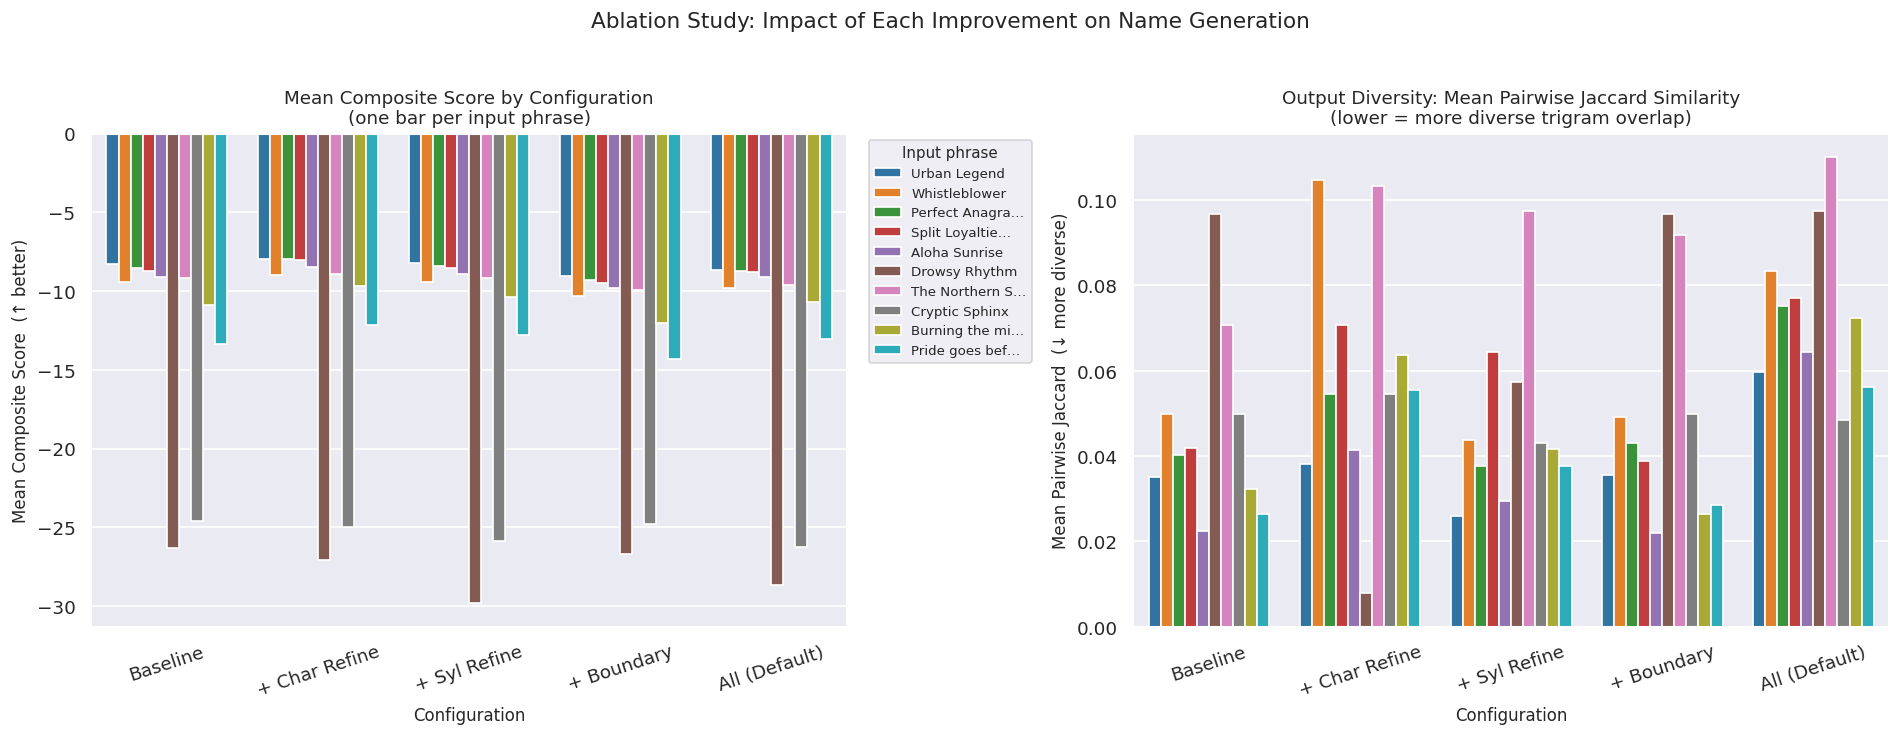

Saved → /home/kbest/github/bu-cds-llms-sp26-portfolio-piece-1-portfolio-piece-KristenBestavros/outputs/ablation_study.png


In [5]:
# ---------------------------------------------------------------------------
# Visualizations
# ---------------------------------------------------------------------------
# Short labels for phrase legend (keep figure readable)
PHRASE_SHORT = {p: (p[:14] + "\u2026" if len(p) > 14 else p) for p in TEST_PHRASES}
df_plot = df_ab.copy()
df_plot["phrase_label"] = df_plot["phrase"].map(PHRASE_SHORT)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── Left: grouped bar — mean composite score by configuration and phrase ─────
sns.barplot(
    data=df_plot,
    x="config",
    y="mean_score",
    hue="phrase_label",
    order=CONFIG_ORDER,
    errorbar=None,
    palette="tab10",
    ax=axes[0],
)
axes[0].set_title(
    "Mean Composite Score by Configuration\n(one bar per input phrase)",
    fontsize=11,
)
axes[0].set_xlabel("Configuration", fontsize=10)
axes[0].set_ylabel("Mean Composite Score  (\u2191 better)", fontsize=10)
axes[0].tick_params(axis="x", rotation=18)
axes[0].legend(
    title="Input phrase",
    fontsize=8,
    title_fontsize=9,
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
)

# ── Right: mean pairwise Jaccard similarity (lower = more diverse) ───────────
sns.barplot(
    data=df_plot,
    x="config",
    y="mean_pairwise_jaccard",
    hue="phrase_label",
    order=CONFIG_ORDER,
    errorbar=None,
    palette="tab10",
    ax=axes[1],
    legend=False,
)
axes[1].set_title(
    "Output Diversity: Mean Pairwise Jaccard Similarity\n(lower = more diverse trigram overlap)",
    fontsize=11,
)
axes[1].set_xlabel("Configuration", fontsize=10)
axes[1].set_ylabel("Mean Pairwise Jaccard  (\u2193 more diverse)", fontsize=10)
axes[1].tick_params(axis="x", rotation=18)

plt.suptitle(
    "Ablation Study: Impact of Each Improvement on Name Generation",
    fontsize=13,
    y=1.02,
)
plt.tight_layout()

out_path = OUTPUT_DIR / "ablation_study.png"
plt.savefig(out_path, dpi=120, bbox_inches="tight")
plt.show()
print(f"Saved \u2192 {out_path}")

### Interpretation

The results here show that, from a numbers perspective, every additional feature except for character swapping makes the scores more negative, indicating worse results. Similarly, every additional feature (including character swapping) increases the Jaccard score, which indicates less diverse results. From a numbers perspective, then, these features have a negative impact on model performance. However, as I stated previously, the quality of a name is impossible to truly quantify, so we cannot rely on the numbers to tell us the full story.

A good qualitative demonstration of each feature's impact can be seen in the example outputs shown after the summary statistics in the previous cell. For 'Whistleblower,' the baseline names, while pronounceable, don't really feel like names. Additionally, all of the top 3 last names start with 'B' or 'Br', and they all grouped the two L's together (Whollew, Welleth, Brillow). Comparatively, the top 3 after each subsequent refinement are much more interesting, and sound much more name-like. "Sherwit Bowell" from character refinement is much more name-like than the baseline options, and "Wilberth Lowse" from syllable refinement is a personal favorite, especially as it shows that this feature helped the model finally separate the two L's, which lead to better-sounding and more diverse results. Even the boundary scoring alone, which doesn't actually change how the anagrams are produced, boosted "Borthew Wilsel" to the top 3, which I like better than any of the baseline options.

We see similar patterns in the other example phrases. "The Northern Star" is an example phrase chosen because of the abundance of common English bigrams and high-frequency letters, and the impact on the final anagrams is obvious; in the baseline model, all of the top 3 start with "Shar" and include a double T in the surname. Character refinement improved the diversity of starting sounds and even resulted in two of the names avoiding the double T that plagued the baseline options. Syllable refinement resulted in an abundance of 'th' bigrams, but the results are still more diverse and interesting names than the baseline. Boundary scoring in this case had very little impact, but the complete model with all 3 improvements is a noticeable improvement over the baseline. We see similar incremental improvements with "Urban Legend," a phrase with great vowel ratios and consonant combinations, which went from anagrams like "Belang Under" in the baseline to "Gauld Bernen" and "Lugan Denber" with the full model.

The phrase "Cryptic Sphinx" is an interesting case, chosen for its low vowel ratio and abundance of uncommon letters and bigrams. Interestingly, in this case I think the best option was generated with character refinement alone. The highest-scoring name in that case was "Cypinx Spritch," which not only sounds like a name befitting a sci-fi or fantasy setting, but is the only name generated from this phrase that has the "First Last" template. I am unsure why this is, nor am I completely sure about why the different features impacted this phrase differently from the rest of the example phrases. The obvious answer is that the available letters are just too difficult, but this doesn't explain why the model insists on choosing templates that result in such short name segments. Regardless of this anomaly, qualitatively I think it is obvious that each of these refinements has value and should remain in the model.

I also think it's important to note that the character and syllable swapping increased the number of valid anagrams generated for the phrase "Drowsy Rhythm," which has a very low vowel ratio and a high number of uncommon consonant combinations. The number of returned anagrams for this phrase increased from 3 at the baseline to 12 in the full model -- four times the baseline model. This idicates that another benefit of these features is the ability to deal with difficult phrases more robustly.

# 4. Temperature and Diversity Analysis

Temperature is the single most interpretable knob in this system. In the Markov
sampler (`src/solver.py: weighted_sample`), every candidate character's
log-probability is divided by `temperature` before the softmax-like
exponentiation:

$$w_c = \exp\!\bigl((\log p_c - \log p_{\max}) \;/\; T\bigr)$$

- **T → 0**: distribution collapses onto the single most-probable character
  (greedy decoding). Every run produces the same few names — low diversity,
  high Markov score.
- **T = 1**: probabilities are used as-is; the model samples proportionally to
  the learned n-gram distribution.
- **T → ∞**: distribution becomes uniform over all available letters; outputs
  approach random permutations — high diversity, low score.

This reflects what we learned about temperature in class, with higher temperatures flattening probabilities and leading to less probable but more 'creative' results. The application to anagrams is different, though. Instead of predicting the next word in a sentence, we are predicting the next letter in a name, and the model does not get to choose from all 26 letters -- it is limited by the available letter pool, the size of which decreases with every chosen letter. By the end, the temperature has no effect at all, as there is only one letter to choose from no matter its assigned probability. This does not mean that temperature is meaningless in this model, however -- higher temperatures at the start of name construction could lead to the selection of a less likely starting letter or bigram, leading to more interesting final results. 

The generator's default schedule linearly escalates from `TEMP_MIN=1.2` to
`TEMP_MAX=2.0` across 500 attempts to balance early quality with late
diversity; this was a design recommendation from Claude which I thought sounded beneficial given the limitations of anagram generation. To understand the impact of temperature, however, we will be holding temperature constant for this part of the analysis (`temp_min = temp_max = T`).

**Phrases** (short / medium / high-vowel / long to reveal length- and
letter-composition-dependent effects):

| Phrase | Letters |
|---|---|
| "Urban Legend" | 11 |
| "Whistleblower" | 13 |
| "Aloha Sunrise" | 12 (high vowel ratio) |
| "Pride goes before the fall" | 22 |

**Metrics** recorded per (temperature × phrase):
- **Mean composite score** — quality (higher is better)
- **Mean pairwise Jaccard trigram similarity** — diversity proxy (lower = more diverse)
- **Mean pairwise Levenshtein distance** — structural diversity

In [6]:
# ---------------------------------------------------------------------------
# Experiment parameters
# ---------------------------------------------------------------------------

TEMP_PHRASES = [
    "Urban Legend",                # 11 letters — short
    "Whistleblower",               # 13 letters — medium
    "Aloha Sunrise",               # 12 letters — high vowel ratio
    "Pride goes before the fall",  # 22 letters — long
]

TEMPS         = [0.5, 0.8, 1.0, 1.2, 1.5, 2.0, 2.5, 3.0, 4.0]
TEMP_SEED     = 42
TEMP_NRESULTS = 30

TEMP_PHRASE_LABELS = {
    "Urban Legend":                '"Urban Legend"  (11 letters)',
    "Whistleblower":               '"Whistleblower"  (13 letters)',
    "Aloha Sunrise":               '"Aloha Sunrise"  (12 letters, high vowels)',
    "Pride goes before the fall":  '"Pride goes before the fall"  (22 letters)',
}

# ---------------------------------------------------------------------------
# Temperature sweep
# ---------------------------------------------------------------------------
# Setting temp_min = temp_max = T forces a constant temperature throughout
# the 500 solve attempts, equivalent to the CLI --temp flag.

temp_rows = []

for phrase in TEMP_PHRASES:
    n_let = len(normalize(phrase))
    print(f"\n── {phrase!r}  ({n_let} letters) ──")

    for t in TEMPS:
        random.seed(TEMP_SEED)
        results = _gen.generate(
            phrase,
            n_results=TEMP_NRESULTS,
            temp_min=t,
            temp_max=t,        # constant temperature
        )

        scores = [s for _, s, _, _ in results]
        names  = [n for n, _, _, _ in results]

        mean_sc  = float(np.mean(scores)) if scores else float("nan")
        mpj      = mean_pairwise_jaccard(names)

        temp_rows.append({
            "phrase":               phrase,
            "n_letters":            n_let,
            "temp":                 t,
            "mean_score":           mean_sc,
            "mean_pairwise_jaccard": mpj
        })

        print(
            f"  T={t:<4.1f}  n={len(results):2d}/{TEMP_NRESULTS}"
            f"  score={mean_sc:6.2f}"
            f"  jaccard={mpj:.3f}"
        )


── 'Urban Legend'  (11 letters) ──
  T=0.5   n=30/30  score= -8.79  jaccard=0.045
  T=0.8   n=30/30  score= -8.77  jaccard=0.054
  T=1.0   n=30/30  score= -8.80  jaccard=0.059
  T=1.2   n=30/30  score= -8.75  jaccard=0.053
  T=1.5   n=30/30  score= -8.83  jaccard=0.046
  T=2.0   n=30/30  score= -8.88  jaccard=0.044
  T=2.5   n=30/30  score= -8.81  jaccard=0.052
  T=3.0   n=30/30  score= -8.79  jaccard=0.045
  T=4.0   n=30/30  score= -8.85  jaccard=0.048

── 'Whistleblower'  (13 letters) ──
  T=0.5   n=30/30  score= -9.97  jaccard=0.069
  T=0.8   n=30/30  score=-10.03  jaccard=0.058
  T=1.0   n=30/30  score=-10.08  jaccard=0.059
  T=1.2   n=30/30  score=-10.17  jaccard=0.061
  T=1.5   n=30/30  score= -9.97  jaccard=0.067
  T=2.0   n=30/30  score=-10.11  jaccard=0.067
  T=2.5   n=30/30  score= -9.96  jaccard=0.067
  T=3.0   n=30/30  score=-10.02  jaccard=0.067
  T=4.0   n=30/30  score=-10.06  jaccard=0.066

── 'Aloha Sunrise'  (12 letters) ──
  T=0.5   n=30/30  score= -9.19  jaccard=0.0

In [7]:
from IPython.display import display

df_temp = pd.DataFrame(temp_rows)

# Helper: shorten long phrase names for table row labels
def short_phrase(p, maxlen=22):
    return p[:maxlen] + "\u2026" if len(p) > maxlen else p

# ── Mean composite score × temperature ─────────────────────────────────────
pivot_score = (
    df_temp
    .pivot(index="phrase", columns="temp", values="mean_score")
    .rename(index=short_phrase)
    .round(2)
)
pivot_score.index.name  = "Phrase"
pivot_score.columns.name = "Temperature"

print("=" * 72)
print("  Mean Composite Score  (higher = better quality)")
print("=" * 72)
display(pivot_score)

# ── Mean pairwise Jaccard × temperature ────────────────────────────────────
pivot_jac = (
    df_temp
    .pivot(index="phrase", columns="temp", values="mean_pairwise_jaccard")
    .rename(index=short_phrase)
    .round(3)
)
pivot_jac.index.name   = "Phrase"
pivot_jac.columns.name = "Temperature"

print("\n" + "=" * 72)
print("  Mean Pairwise Jaccard Similarity  (lower = more diverse)")
print("=" * 72)
display(pivot_jac)

  Mean Composite Score  (higher = better quality)


Temperature,0.5,0.8,1.0,1.2,1.5,2.0,2.5,3.0,4.0
Phrase,,,,,,,,,
Aloha Sunrise,-9.19,-9.18,-9.20,-9.27,-9.21,-9.25,-9.24,-9.23,-9.27
Pride goes before the …,-13.10,-13.21,-13.21,-13.25,-13.37,-13.37,-13.36,-13.36,-13.38
Urban Legend,-8.79,-8.77,-8.80,-8.75,-8.83,-8.88,-8.81,-8.79,-8.85
Whistleblower,-9.97,-10.03,-10.08,-10.17,-9.97,-10.11,-9.96,-10.02,-10.06



  Mean Pairwise Jaccard Similarity  (lower = more diverse)


Temperature,0.5,0.8,1.0,1.2,1.5,2.0,2.5,3.0,4.0
Phrase,,,,,,,,,
Aloha Sunrise,0.064,0.056,0.051,0.040,0.050,0.058,0.042,0.045,0.039
Pride goes before the …,0.055,0.048,0.052,0.048,0.052,0.047,0.050,0.044,0.043
Urban Legend,0.045,0.054,0.059,0.053,0.046,0.044,0.052,0.045,0.048
Whistleblower,0.069,0.058,0.059,0.061,0.067,0.067,0.067,0.067,0.066


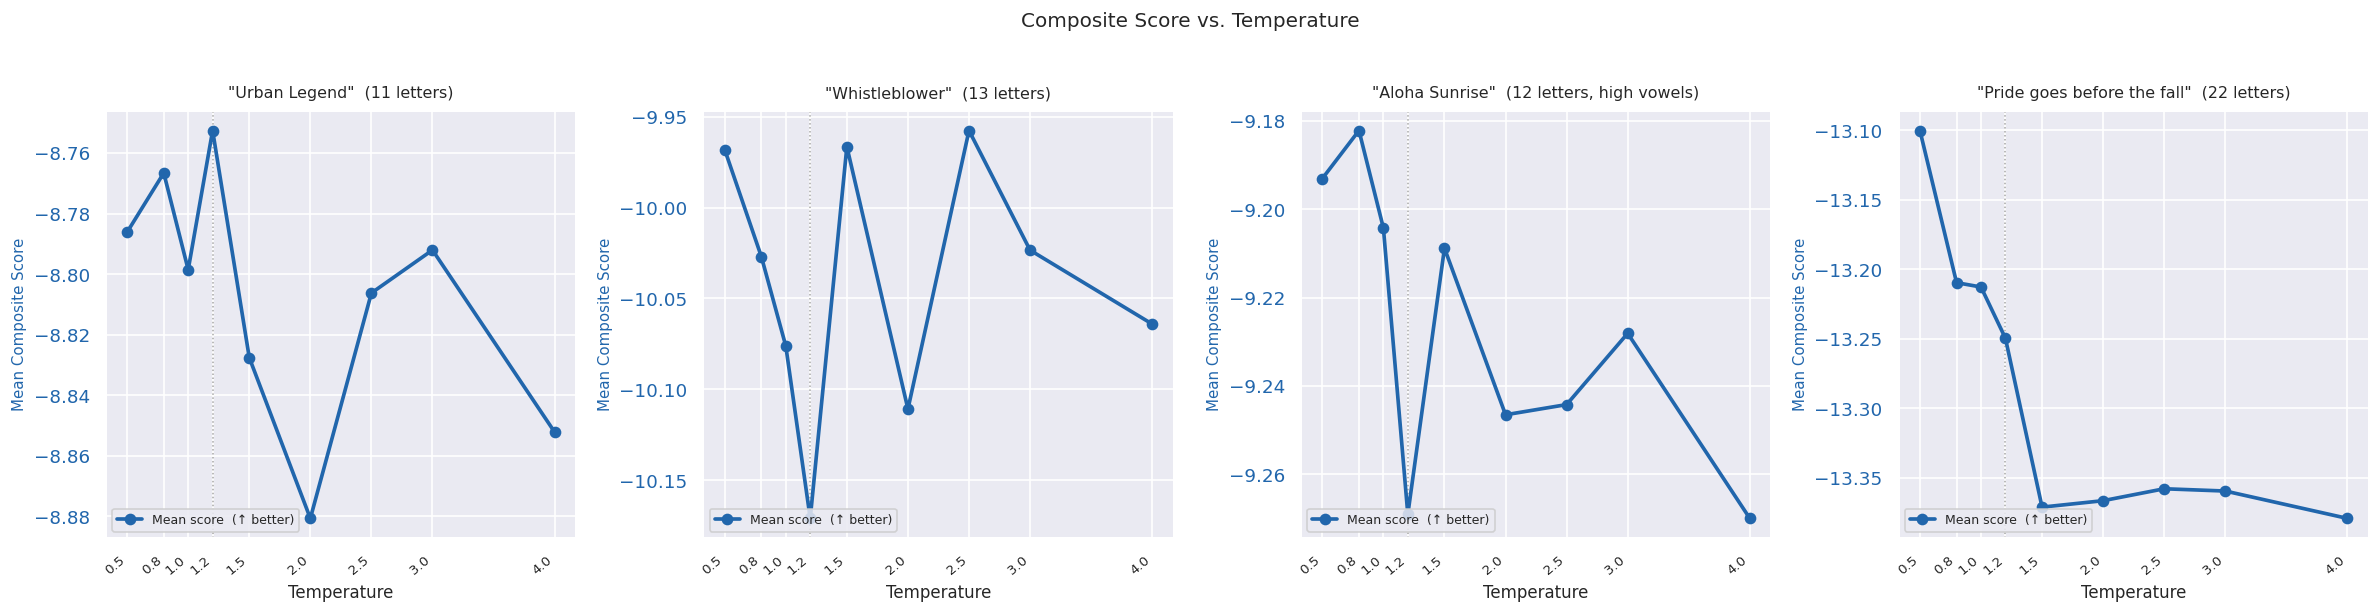

Saved → /home/kbest/github/bu-cds-llms-sp26-portfolio-piece-1-portfolio-piece-KristenBestavros/outputs/temperature_quality.png


In [8]:
# ---------------------------------------------------------------------------
# Figure: Composite Score vs. Temperature — one subplot per phrase
# ---------------------------------------------------------------------------
C_SCORE  = "#2166ac"   # blue  — composite score

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

for ax, phrase in zip(axes, TEMP_PHRASES):
    sub = df_temp[df_temp["phrase"] == phrase].sort_values("temp")

    # ── Mean composite score ────────────────────────────────────────────────
    l1, = ax.plot(
        sub["temp"], sub["mean_score"],
        color=C_SCORE, marker="o", linewidth=2.2, zorder=3,
        label="Mean composite score  (\u2191 better)",
    )
    ax.set_xlabel("Temperature", fontsize=10)
    ax.set_ylabel("Mean Composite Score", color=C_SCORE, fontsize=9)
    ax.tick_params(axis="y", labelcolor=C_SCORE)
    ax.set_xticks(TEMPS)
    ax.set_xticklabels([str(t) for t in TEMPS], rotation=40, ha="right", fontsize=8)
    ax.set_title(TEMP_PHRASE_LABELS[phrase], fontsize=9.5, pad=8)

    # ── Reference line at the default TEMP_MIN ─────────────────────────────
    ax.axvline(x=1.2, color="grey", linewidth=0.9, linestyle=":", alpha=0.7,
               label="Default TEMP_MIN=1.2")

    # ── Legend ─────────────────────────────────────────────────────────────
    legend = ax.legend(
        [l1],
        ["Mean score  (\u2191 better)"],
        loc="lower left", fontsize=7.5, framealpha=0.85,
    )
    legend.set_zorder(10)

plt.suptitle(
    "Composite Score vs. Temperature",
    fontsize=12, y=1.02,
)
plt.tight_layout()

out_path = OUTPUT_DIR / "temperature_quality.png"
plt.savefig(out_path, dpi=120, bbox_inches="tight")
plt.show()
print(f"Saved \u2192 {out_path}")


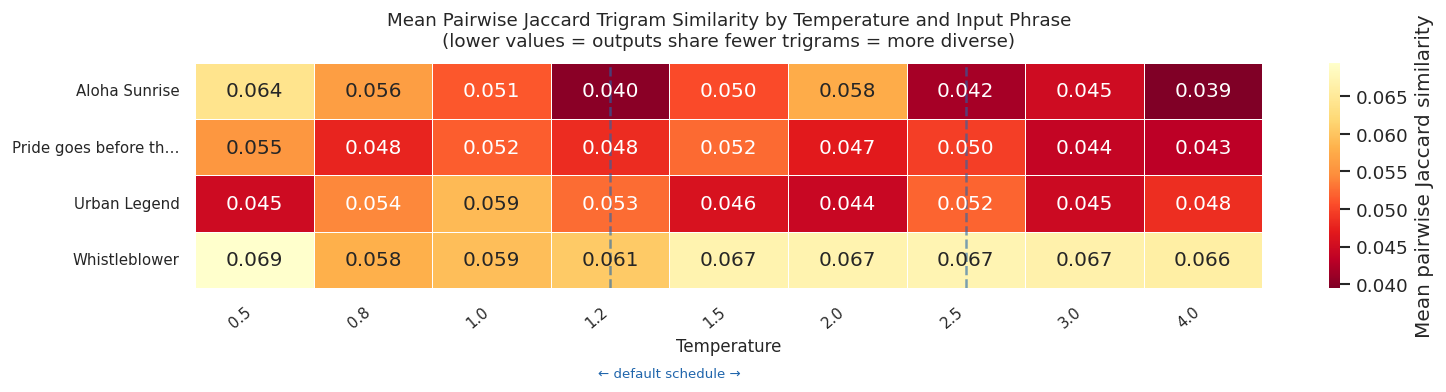

Saved → /home/kbest/github/bu-cds-llms-sp26-portfolio-piece-1-portfolio-piece-KristenBestavros/outputs/temperature_diversity_jaccard.png


In [9]:
# ---------------------------------------------------------------------------
# Figure: Heatmap — mean pairwise Jaccard similarity (trigram diversity)
# ---------------------------------------------------------------------------
pivot_jac_plot = (
    df_temp
    .pivot(index="phrase", columns="temp", values="mean_pairwise_jaccard")
)
row_labels_jac = [short_phrase(p, maxlen=20) for p in pivot_jac_plot.index]

fig, ax = plt.subplots(figsize=(13, 3.8))
sns.heatmap(
    pivot_jac_plot,
    annot=True,
    fmt=".3f",
    cmap="YlOrRd_r",   # reversed: lower Jaccard (more diverse) = warmer colour
    linewidths=0.4,
    linecolor="white",
    cbar_kws={"label": "Mean pairwise Jaccard similarity"},
    ax=ax,
)
ax.set_title(
    "Mean Pairwise Jaccard Trigram Similarity by Temperature and Input Phrase\n"
    "(lower values = outputs share fewer trigrams = more diverse)",
    fontsize=11, pad=10,
)
ax.set_xlabel("Temperature", fontsize=10)
ax.set_ylabel("")
ax.set_yticklabels(row_labels_jac, rotation=0, fontsize=9)
ax.set_xticklabels([str(t) for t in TEMPS], rotation=40, ha="right", fontsize=9)

# Annotate default operating range
ax.axvline(x=list(TEMPS).index(1.2) + 0.5,
           color="#2166ac", linewidth=1.5, linestyle="--", alpha=0.6)
ax.axvline(x=list(TEMPS).index(2.0) + 1.5,
           color="#2166ac", linewidth=1.5, linestyle="--", alpha=0.6)
ax.text(
    list(TEMPS).index(1.2) + 1.0, -0.35,
    "\u2190 default schedule \u2192", color="#2166ac",
    ha="center", va="top", fontsize=8, transform=ax.get_xaxis_transform(),
)

plt.tight_layout()

out_path = OUTPUT_DIR / "temperature_diversity_jaccard.png"
plt.savefig(out_path, dpi=120, bbox_inches="tight")
plt.show()
print(f"Saved \u2192 {out_path}")

In [10]:
# ---------------------------------------------------------------------------
# Qualitative examples: top-3 names at representative temperatures
# ---------------------------------------------------------------------------
# Re-run at a few fixed temperatures for select phrases so the interpretation
# can point to concrete before/after examples rather than numbers alone.

QUAL_TEMPS   = [0.5, 1.2, 2.0, 4.0]
QUAL_TEMP_PHRASES = ["Whistleblower", "Urban Legend", "Aloha Sunrise", "Pride goes before the fall"]

print("Generating qualitative examples across temperatures...")
for phrase in QUAL_TEMP_PHRASES:
    print(f"\n{'='*70}")
    print(f"  Phrase: '{phrase}'")
    print(f"{'='*70}")
    for t in QUAL_TEMPS:
        random.seed(TEMP_SEED)
        results = _gen.generate(
            phrase,
            n_results=10,
            temp_min=t,
            temp_max=t,
            allow_words=True,
        )
        names   = [n for n, _, _, _ in results]
        scores  = [s for _, s, _, _ in results]
        top3_str = "  |  ".join(names[:3]) if names else "(no results)"
        mean_sc  = float(np.mean(scores)) if scores else float("nan")
        print(f"  T={t:<4.1f}  score={mean_sc:6.2f}  \u2192  {top3_str}")


Generating qualitative examples across temperatures...

  Phrase: 'Whistleblower'
  T=0.5   score= -9.65  →  Bellows Wither  |  Withel Browles  |  Belle Rowswith
  T=1.2   score= -9.79  →  Willwes Bother  |  Wherste Bowill  |  Willew Bothers
  T=2.0   score= -9.73  →  Withers Bellow  |  Theber Willows  |  Bethe Rowswill
  T=4.0   score= -9.66  →  Bether Willows  |  Withel Lebrows  |  Shebert Willow

  Phrase: 'Urban Legend'
  T=0.5   score= -8.49  →  Gunden Baler  |  Gundel Beran  |  Gunne Balder
  T=1.2   score= -8.53  →  Burgen Delan  |  Gunda Bernel  |  Gundel Beran
  T=2.0   score= -8.58  →  Gunden Baler  |  Gundal Berne  |  Bered Lungan
  T=4.0   score= -8.59  →  Burgen Delan  |  Gundel Beran  |  Guald Bernen

  Phrase: 'Aloha Sunrise'
  T=0.5   score= -9.00  →  Alous Hersian  |  Halaus Sonier  |  Elous Harians
  T=1.2   score= -9.10  →  Alius Hersona  |  Holaus Sianer  |  Roshaus Elian
  T=2.0   score= -9.08  →  Harius Aleson  |  Hoelius Saran  |  Lanous Haries
  T=4.0   score= -

### Interpretation

As expected, increased temperature is associated with lower-scoring anagrams with lower Jaccard scores. In other words, as temperature increases, the values for our quality heuristic worsen, but the results are more diverse. That is what the numbers say, anyway; looking at the example outputs, it is a little harder to tell what difference temperature really had. Most of the results for most of the phrases are quite good regardless of temperature; interestingly, I think the worst results came from the runs with 1.2 temperature. It's most obvious with "Whistleblower" and "Pride goes before the fall," specifically with the first names. With "Whistleblower," 1.2 temperature produced the first names "Wherste" and "Willwes," which make very little sense phonetically and look strange regardless. These results were much worse than the names generated with other temperatures; in fact, at T=0.5 the model generated the first name "Belle," which is a real name. Similarly, T=1.2 with "Pride goes before the fall" produced the first names "Pellee" and "Shold," while T=2.0 produced "Progia," "Deliah," and "Teriah."

I'm unsure why T=1.2 seems to produce worse results than other temperatures. It could also be an anomaly with my chosen example phrases, though my observations are somewhat supported by the numerical results -- you can see in the score graph for each phrase that score start out quite high, drop sharply, but bounce back a little bit between T=2.0 and T=3.0. This is interesting to me and may indicate that I should change the increase of temperatures used in my model to capture high-quality names on both ends of the temperature spectrum.

## 5. Sampling Strategy: Top-k vs. Top-p

In class, we discussed different selection strategies for text generation. Specifically, we covered top-k and top-p, and discussed the situations in which each may be useful. Neither of these methods is used in the anagrammer currently -- it is unnecessary since the pool of available letters is, by nature, limited. There is no real computational cost to unrestricted selection, and since we are dealing with letters rather than words, we don't really have to worry about low-probability options making the output nonsensical. That said, I think there could be a place for restricted selection strategies in the anagrammer. Specifically, I wonder if truncating the letter options during letter generation will prevent the model from picking a low-probability letter that could be better placed later on in the anagram. In this section, we experiment with this a little bit. 

The `weighted_sample(candidates, temperature)` function in `src/solver.py` is called
character-by-character during segment construction — directly analogous to token
selection in language model decoding. Here we compare three sampling strategies:

| Strategy | Description |
|---|---|
| **Unrestricted** | Current behaviour: sample over the full available-letter pool |
| **Top-k** | Truncate to the *k* highest-probability letters before sampling |
| **Top-p (nucleus)** | Truncate to the smallest set whose cumulative probability ≥ *p* |

**Important caveat**: unlike LLM vocabularies (50k+ tokens), the letter bag is a
constrained pool of typically 5–20 distinct characters. This means:
- Top-k with k ≥ pool size = unrestricted sampling (no filtering occurs)
- The effect of both strategies diminishes as the bag depletes toward end-of-segment

Run on the 4 `TEMP_PHRASES`, seed=42, 15 results each, at default temperature 1.2.


── Unrestricted ──
  Urban Legend                    score= -8.61  jaccard=0.078
  Whistleblower                   score= -9.87  jaccard=0.086
  Aloha Sunrise                   score= -9.15  jaccard=0.049
  Pride goes before the fall      score=-13.20  jaccard=0.051

── Top-k  k=3 ──
  Urban Legend                    score= -8.64  jaccard=0.055
  Whistleblower                   score= -9.73  jaccard=0.102
  Aloha Sunrise                   score= -9.12  jaccard=0.065
  Pride goes before the fall      score=-12.91  jaccard=0.063

── Top-k  k=5 ──
  Urban Legend                    score= -8.56  jaccard=0.075
  Whistleblower                   score= -9.82  jaccard=0.081
  Aloha Sunrise                   score= -9.12  jaccard=0.054
  Pride goes before the fall      score=-12.93  jaccard=0.076

── Top-k  k=8 ──
  Urban Legend                    score= -8.56  jaccard=0.077
  Whistleblower                   score= -9.78  jaccard=0.092
  Aloha Sunrise                   score= -9.05  jaccard=0.

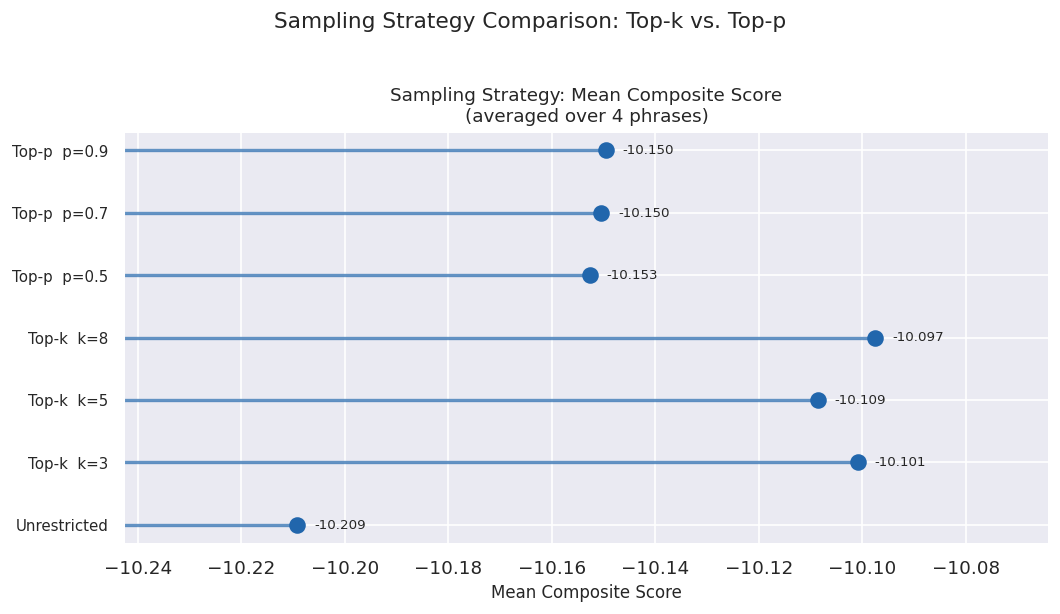

Saved → /home/kbest/github/bu-cds-llms-sp26-portfolio-piece-1-portfolio-piece-KristenBestavros/outputs/sampling_strategy_quality.png


In [29]:
# ---------------------------------------------------------------------------
# Sampling strategy implementations (monkey-patch weighted_sample)
# ---------------------------------------------------------------------------

_orig_ws = _sol_mod.weighted_sample

def _topk_ws(candidates, temperature, k):
    """Top-k sampling: keep only the k highest-log-prob candidates."""
    if len(candidates) <= k:
        return _orig_ws(candidates, temperature)
    top = sorted(candidates, key=lambda x: x[1], reverse=True)[:k]
    return _orig_ws(top, temperature)


def _topp_ws(candidates, temperature, p):
    """Top-p (nucleus) sampling: keep smallest set with cumulative prob >= p."""
    if not candidates:
        return None
    sorted_cands = sorted(candidates, key=lambda x: x[1], reverse=True)
    max_lp = sorted_cands[0][1]
    weights = [math.exp((lp - max_lp) / temperature) for _, lp in sorted_cands]
    total = sum(weights)
    cumsum = 0.0
    nucleus = []
    for i, (char, lp) in enumerate(sorted_cands):
        nucleus.append((char, lp))
        cumsum += weights[i] / total
        if cumsum >= p:
            break
    return _orig_ws(nucleus, temperature)


def run_sampling_strategy(generator, phrase, ws_fn, n_results=15, seed=TEMP_SEED):
    """Run generation with a specific weighted_sample replacement."""
    orig_ws = _sol_mod.weighted_sample
    random.seed(seed)
    try:
        _sol_mod.weighted_sample = ws_fn
        results = generator.generate(
            phrase, n_results=n_results, temp_min=1.2, temp_max=1.2,
            allow_words=True,
        )
    finally:
        _sol_mod.weighted_sample = orig_ws
    return results


# ---------------------------------------------------------------------------
# Strategy definitions
# ---------------------------------------------------------------------------
STRATEGIES = {
    "Unrestricted":  _orig_ws,
    "Top-k  k=3":   functools.partial(_topk_ws, k=3),
    "Top-k  k=5":   functools.partial(_topk_ws, k=5),
    "Top-k  k=8":   functools.partial(_topk_ws, k=8),
    "Top-p  p=0.5": functools.partial(_topp_ws, p=0.5),
    "Top-p  p=0.7": functools.partial(_topp_ws, p=0.7),
    "Top-p  p=0.9": functools.partial(_topp_ws, p=0.9),
}
STRATEGY_ORDER = list(STRATEGIES)

# ---------------------------------------------------------------------------
# Run sweep
# ---------------------------------------------------------------------------
strat_rows = []

for strat_name, ws_fn in STRATEGIES.items():
    print(f"\n── {strat_name} ──")
    for phrase in TEMP_PHRASES:
        results = run_sampling_strategy(_gen, phrase, ws_fn)
        scores = [s for _, s, _, _ in results]
        names  = [n for n, _, _, _ in results]
        mean_sc = float(np.mean(scores)) if scores else float("nan")
        mpj     = mean_pairwise_jaccard(names)
        strat_rows.append({
            "strategy":             strat_name,
            "phrase":               phrase,
            "mean_score":           mean_sc,
            "mean_pairwise_jaccard": mpj,
        })
        print(
            f"  {phrase:28s}  "
            f"  score={mean_sc:6.2f}  jaccard={mpj:.3f}"
        )

df_strat = pd.DataFrame(strat_rows)
print("\nDone.")

# ---------------------------------------------------------------------------
# Figure: Quality and diversity by sampling strategy
# ---------------------------------------------------------------------------
# Aggregate over phrases
agg_strat = (
    df_strat
    .groupby("strategy")
    .agg(
        mean_score             =("mean_score",            "mean"),
        mean_pairwise_jaccard  =("mean_pairwise_jaccard", "mean"),
    )
    .loc[STRATEGY_ORDER]
    .reset_index()
)

fig, ax = plt.subplots(1, 1, figsize=(9, 5))

y_pos = range(len(STRATEGY_ORDER))
scores = agg_strat["mean_score"]

# Horizontal lollipop chart
ax.hlines(y=y_pos, xmin=scores.min() - 0.05, xmax=scores, color="#2166ac", alpha=0.7, linewidth=2)
ax.scatter(scores, y_pos, color="#2166ac", s=80, zorder=3)

# Tight x-axis around the actual data range
padding = (scores.max() - scores.min()) * 0.3
ax.set_xlim(scores.min() - padding, scores.max() + padding)

ax.set_yticks(list(y_pos))
ax.set_yticklabels(STRATEGY_ORDER, fontsize=9)
ax.set_xlabel("Mean Composite Score", fontsize=10)
ax.set_title(
    "Sampling Strategy: Mean Composite Score\n(averaged over 4 phrases)",
    fontsize=11,
)

# Annotate values on each dot
for i, score in enumerate(scores):
    ax.annotate(f"{score:.3f}", (score, i), textcoords="offset points",
                xytext=(10, 0), fontsize=8, va="center")

plt.suptitle("Sampling Strategy Comparison: Top-k vs. Top-p", fontsize=13, y=1.02)
plt.tight_layout()

out_path = OUTPUT_DIR / "sampling_strategy_quality.png"
plt.savefig(out_path, dpi=120, bbox_inches="tight")
plt.show()
print(f"Saved → {out_path}")


### Interpretation

The results show that, from a numbers perspective at least, both top-p and top-k methods improve scores. Indeed, unrestricted selection has the worst scores by up to .1 points in some cases. Interestingly, top-k performed better than top-p here. I'm not sure why, though if I had to guess, I would say that top-k is a more consistent truncation of possible results, and as such had a greater effect. With top-p, it's very easy for it to end up working like greedy selection in cases where one letter has a very high probability, or like unrestricted selection in cases where the letters have very low individual probabilities. With top-k, you can be sure that there is room for randomness while still limiting letter options.

It's worth noting that the length of the input phrase likely has a lot to do with how these methods performed. Our phrases varied in length from 11 to 22 letters, and repeat letters also impact the letter pools. We can see from the raw numbers that the longest phrase, "Pride goes before the fall," saw the greatest score improvement with every sampling method, while shorter inputs with repeat letters like "Whistleblower" actually had worse scores for some sampling methods.

My overall takeaway here is that it may be worth implementing a top-k sampling method for very long inputs, but for regular inputs, the score improvement is modest at best and negative at worst, so unrestricted selection is a better, more consistent option.


# 6. Dataset Comparison: Male vs. Female vs. Both

In an effort to capture style differences in male and female names, I grouped and labeled the training names as follows:

| Dataset | Training files | ~Size |
|---|---|---|
| `male` | `male_first.txt` | 47,510 names |
| `female` | `female_first.txt` | 39,414 names |
| `both` | both of the above | 86,924 names |

All three also use `surnames.txt` (18,905 names). The question is whether the different first-name datasets leave a
measurable imprint on generated outputs. Specifically, I am curious as to whether the model successfulyl learns the associations of different name endings. There are patterns associated with name gender, as the following table shows.

**Raw-data baseline** (from file analysis of the training data):

| Corpus | Dominant endings (top-5) | Dominant trigrams (top-5) |
|---|---|---|
| male | `-an`, `-us`, `-on`, `-in`, `-er` | `and`, `ing`, `ara`, `ana`, `har` |
| female | `-na`, `-ia`, `-ne`, `-ra`, `-la` | `sha`, `ana`, `ann`, `ina`, `ell` |
| surnames | `-an`, `-er`, `-en`, `-on`, `-in` | `ian`, `man`, `ell`, `mac`, `son` |

To see if the generated male/female names are meaningfully different, we will look at common trigrams, dataset diversity, and ending patterns.

**Three analyses:**

1. **Character trigram comparison** — frequency heatmap with ★ markers
2. **Within-dataset diversity** — mean pairwise Jaccard per dataset
3. **Ending patterns** — grouped bar chart

All runs: 30 results, `seed=42`, all improvements enabled.

In [12]:

DATASETS      = ["male", "female", "both"]
COMP_SEED     = 42
COMP_NRESULTS = 30
DS_PALETTE    = {"male": "#4878d0", "female": "#ee854a", "both": "#6acc65"}

# ---------------------------------------------------------------------------
# Load per-dataset generators (the "both" generator is already cached as _gen)
# ---------------------------------------------------------------------------
print("Loading male and female generators (both is already cached)\u2026")
_gen_male   = AnagramGenerator(dataset="male")
_gen_female = AnagramGenerator(dataset="female")
_gens = {"male": _gen_male, "female": _gen_female, "both": _gen}
print("Ready.\n")

# ---------------------------------------------------------------------------
# Generation loop: every dataset × every test phrase
# ---------------------------------------------------------------------------
score_rows = []                            # for violin-plot DataFrame
name_score_rows = []                       # for qualitative examples
seg_by_ds  = {ds: [] for ds in DATASETS}  # non-trivial segments per dataset
name_by_ds = {ds: [] for ds in DATASETS}  # full formatted names per dataset

for ds in DATASETS:
    print(f"\n── dataset={ds!r} ──")
    for phrase in TEST_PHRASES:
        random.seed(COMP_SEED)
        results = _gens[ds].generate(phrase, n_results=COMP_NRESULTS)

        scores = [s for _, s, _, _ in results]

        for name, score, label, segs in results:
            score_rows.append({"dataset": ds, "phrase": phrase, "score": score})
            name_score_rows.append({"dataset": ds, "phrase": phrase, "score": score, "name": name})
            # Collect non-trivial segments for n-gram / ending analysis
            seg_by_ds[ds].extend(seg.lower() for seg in segs if len(seg) > 1)
            # Collect full names for within-dataset Jaccard diversity
            name_by_ds[ds].append(name)

        print(
            f"  {phrase:28s}  n={len(results):2d}"
            f"  score={np.mean(scores) if scores else float('nan'):6.2f}"
        )

df_comp = pd.DataFrame(score_rows)
df_comp_named = pd.DataFrame(name_score_rows)

Loading male and female generators (both is already cached)…
Ready.


── dataset='male' ──
  Urban Legend                  n=30  score= -8.72
  Whistleblower                 n=30  score= -9.88
  Perfect Anagram               n=30  score= -8.76
  Split Loyalties               n=30  score= -8.79
  Aloha Sunrise                 n=30  score= -9.14
  Drowsy Rhythm                 n= 7  score=-25.82
  The Northern Star             n=30  score= -9.71
  Cryptic Sphinx                n=30  score=-27.52
  Burning the midnight oil      n=30  score=-11.09
  Pride goes before the fall    n=30  score=-13.27

── dataset='female' ──
  Urban Legend                  n=30  score= -8.66
  Whistleblower                 n=30  score=-10.02
  Perfect Anagram               n=30  score= -8.66
  Split Loyalties               n=30  score= -8.78
  Aloha Sunrise                 n=30  score= -9.11
  Drowsy Rhythm                 n=10  score=-25.58
  The Northern Star             n=30  score= -9.77
  Cryptic Sphinx  

In [14]:
# Qualitative examples: top-3 and bottom-3 per dataset by composite score
for ds in DATASETS:
    sub = df_comp_named[df_comp_named["dataset"] == ds].sort_values("score", ascending=False)
    top3    = sub.head(3)[["name", "phrase", "score"]].reset_index(drop=True)
    bottom3 = sub.tail(3)[["name", "phrase", "score"]].reset_index(drop=True)
    print(f"\n\u2500\u2500 Dataset: {ds!r} \u2500\u2500")
    print("  Top-3 highest scoring:")
    for _, row in top3.iterrows():
        print(f"    {row['name']:<28s}  score={row['score']:6.2f}  (from: {row['phrase']})")
    print("  Bottom-3 lowest scoring:")
    for _, row in bottom3.iterrows():
        print(f"    {row['name']:<28s}  score={row['score']:6.2f}  (from: {row['phrase']})")



── Dataset: 'male' ──
  Top-3 highest scoring:
    Gunden Baler                  score= -5.33  (from: Urban Legend)
    Patioly Stellis               score= -5.43  (from: Split Loyalties)
    Gunda Bernel                  score= -5.47  (from: Urban Legend)
  Bottom-3 lowest scoring:
    Xyc P. R. Pichtins            score=-32.24  (from: Cryptic Sphinx)
    Princxict P. S. Hy            score=-32.34  (from: Cryptic Sphinx)
    Xy P. P. Stichrinc            score=-33.44  (from: Cryptic Sphinx)

── Dataset: 'female' ──
  Top-3 highest scoring:
    Partefer Macgan               score= -5.26  (from: Perfect Anagram)
    Burgen Delan                  score= -5.30  (from: Urban Legend)
    Delen Burgan                  score= -5.42  (from: Urban Legend)
  Bottom-3 lowest scoring:
    Cyx N. S. Tipprich            score=-30.80  (from: Cryptic Sphinx)
    Wyd M. S. Yrhorth             score=-31.40  (from: Drowsy Rhythm)
    Hyw R. D. Strohym             score=-31.67  (from: Drowsy Rhythm)

── 

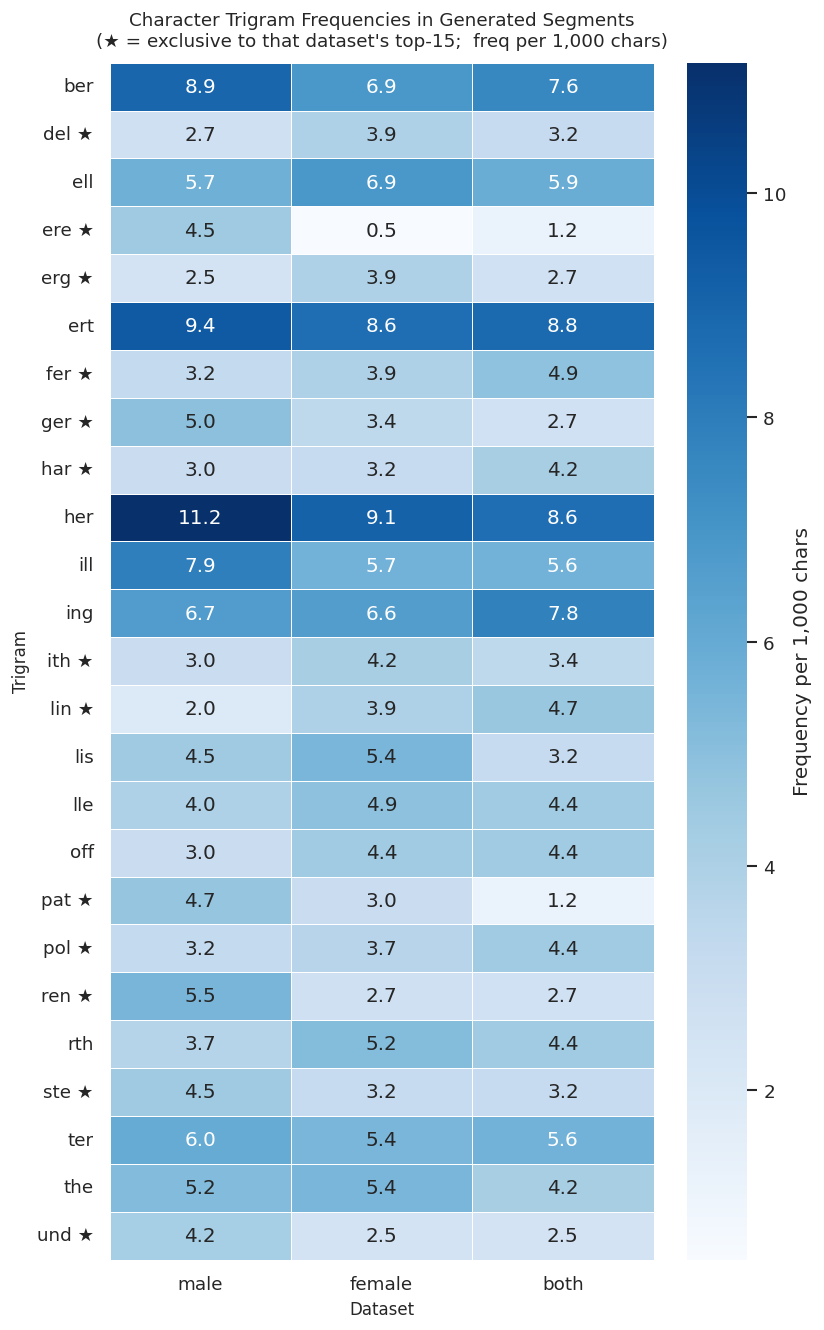

Saved → /home/kbest/github/bu-cds-llms-sp26-portfolio-piece-1-portfolio-piece-KristenBestavros/outputs/dataset_trigrams.png

Exclusive trigrams (appear in exactly one dataset's top-15):
  'del'  → female  (3.9/1k)
  'ere'  → male    (4.5/1k)
  'erg'  → female  (3.9/1k)
  'fer'  → both    (4.9/1k)
  'ger'  → male    (5.0/1k)
  'har'  → both    (4.2/1k)
  'ith'  → female  (4.2/1k)
  'lin'  → both    (4.7/1k)
  'pat'  → male    (4.7/1k)
  'pol'  → both    (4.4/1k)
  'ren'  → male    (5.5/1k)
  'ste'  → male    (4.5/1k)
  'und'  → male    (4.2/1k)

Within-dataset mean pairwise Jaccard similarity (lower = more diverse):
  male  : 0.0122
  female: 0.0112
  both  : 0.0109


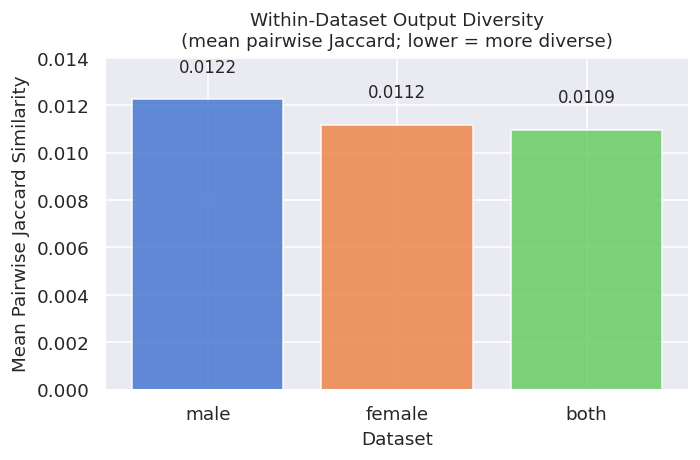

Saved → /home/kbest/github/bu-cds-llms-sp26-portfolio-piece-1-portfolio-piece-KristenBestavros/outputs/dataset_jaccard_diversity.png


In [16]:

from collections import Counter

# ---------------------------------------------------------------------------
# Character trigram frequencies in generated segments
# ---------------------------------------------------------------------------

def ngram_freq_per_1k(segments, n=3):
    """Character n-gram frequency per 1,000 characters."""
    counts = Counter()
    total_chars = 0
    for seg in segments:
        total_chars += len(seg)
        for i in range(len(seg) - n + 1):
            counts[seg[i : i + n]] += 1
    if total_chars == 0:
        return {}
    scale = 1000.0 / total_chars
    return {k: v * scale for k, v in counts.items()}


# Compute per-dataset trigram frequencies
tg_freqs = {ds: ngram_freq_per_1k(seg_by_ds[ds], n=3) for ds in DATASETS}

# Top-15 trigrams for each dataset (by frequency)
top15_per_ds = {
    ds: set(sorted(freq, key=lambda t: -freq[t])[:15])
    for ds, freq in tg_freqs.items()
}
all_top_tgs = sorted(set.union(*top15_per_ds.values()))

# Build heatmap DataFrame (rows = trigrams, columns = datasets)
df_tg = pd.DataFrame(
    {ds: [tg_freqs[ds].get(tg, 0.0) for tg in all_top_tgs] for ds in DATASETS},
    index=all_top_tgs,
)

# Mark trigrams exclusive to exactly one dataset's top-15 with a star
exclusive_to = {tg: [ds for ds in DATASETS if tg in top15_per_ds[ds]] for tg in all_top_tgs}
row_labels = [
    tg + " \u2605" if len(exclusive_to[tg]) == 1 else tg
    for tg in all_top_tgs
]

n_rows = len(all_top_tgs)
fig, ax = plt.subplots(figsize=(7, max(5, n_rows * 0.45)))

sns.heatmap(
    df_tg,
    annot=True,
    fmt=".1f",
    cmap="Blues",
    linewidths=0.3,
    linecolor="white",
    yticklabels=row_labels,
    cbar_kws={"label": "Frequency per 1,000 chars"},
    ax=ax,
)
ax.set_title(
    "Character Trigram Frequencies in Generated Segments\n"
    "(\u2605 = exclusive to that dataset's top-15;  freq per 1,000 chars)",
    fontsize=11,
    pad=10,
)
ax.set_xlabel("Dataset", fontsize=10)
ax.set_ylabel("Trigram", fontsize=10)
ax.set_xticklabels(DATASETS, rotation=0)

plt.tight_layout()
out_path = OUTPUT_DIR / "dataset_trigrams.png"
plt.savefig(out_path, dpi=120, bbox_inches="tight")
plt.show()
print(f"Saved \u2192 {out_path}")

# Print exclusive trigrams for quick reference
print("\nExclusive trigrams (appear in exactly one dataset's top-15):")
any_exclusive = False
for tg in all_top_tgs:
    members = exclusive_to[tg]
    if len(members) == 1:
        freq = tg_freqs[members[0]].get(tg, 0.0)
        print(f"  '{tg}'  \u2192 {members[0]:6s}  ({freq:.1f}/1k)")
        any_exclusive = True
if not any_exclusive:
    print("  (none \u2014 all top-15 trigrams are shared across datasets)")

# ---------------------------------------------------------------------------
# Within-dataset diversity: mean pairwise Jaccard bar chart
# ---------------------------------------------------------------------------
jaccard_by_ds = {ds: mean_pairwise_jaccard(name_by_ds[ds]) for ds in DATASETS}
print("\nWithin-dataset mean pairwise Jaccard similarity (lower = more diverse):")
for ds, jac in jaccard_by_ds.items():
    print(f"  {ds:6s}: {jac:.4f}")

fig, ax = plt.subplots(figsize=(6, 4))
ds_colors = [DS_PALETTE[ds] for ds in DATASETS]
bars = ax.bar(DATASETS, [jaccard_by_ds[ds] for ds in DATASETS], color=ds_colors, alpha=0.85)
for bar, ds in zip(bars, DATASETS):
    ax.text(
        bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.001,
        f"{jaccard_by_ds[ds]:.4f}", ha="center", va="bottom", fontsize=10,
    )
ax.set_xlabel("Dataset", fontsize=11)
ax.set_ylabel("Mean Pairwise Jaccard Similarity", fontsize=11)
ax.set_title(
    "Within-Dataset Output Diversity\n(mean pairwise Jaccard; lower = more diverse)",
    fontsize=11,
)
ax.set_ylim(0, max(jaccard_by_ds.values()) * 1.15)
plt.tight_layout()
out_path = OUTPUT_DIR / "dataset_jaccard_diversity.png"
plt.savefig(out_path, dpi=120, bbox_inches="tight")
plt.show()
print(f"Saved \u2192 {out_path}")

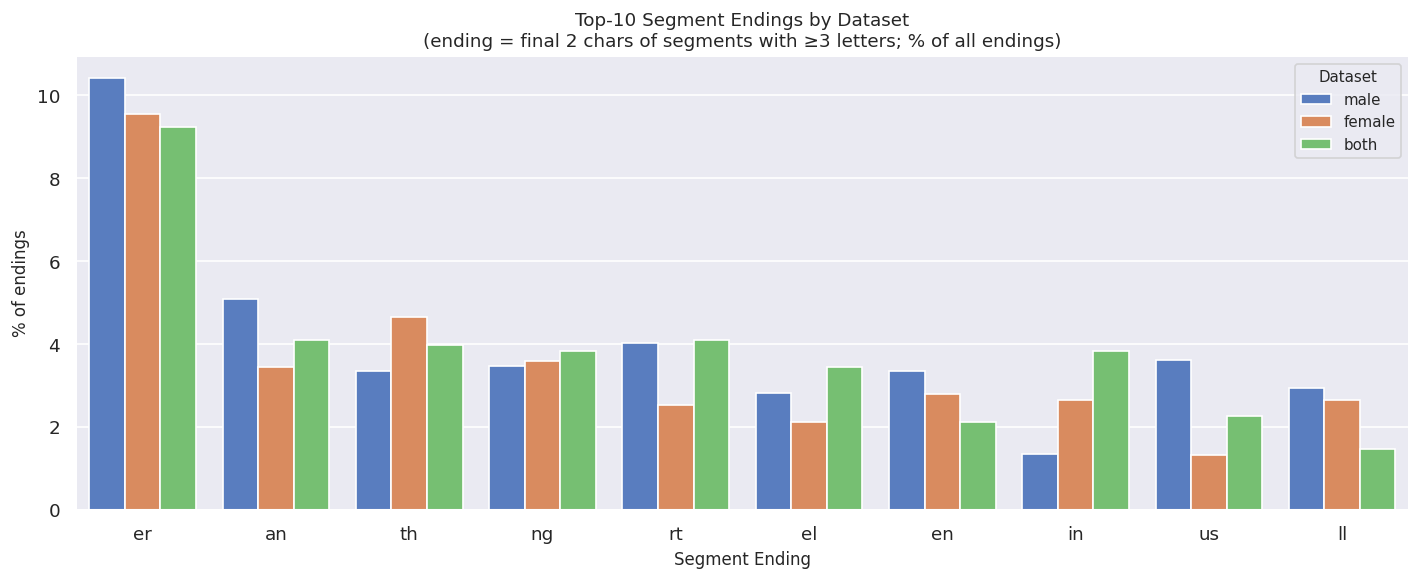

Saved → /home/kbest/github/bu-cds-llms-sp26-portfolio-piece-1-portfolio-piece-KristenBestavros/outputs/dataset_endings.png

Total segments collected per dataset:
  male  :  750 segments,  748 endings (len ≥3)
  female:  757 segments,  754 endings (len ≥3)
  both  :  760 segments,  757 endings (len ≥3)

Top-10 endings (combined rank):
  -er  total= 220  male= 78  female= 72  both= 70
  -an  total=  95  male= 38  female= 26  both= 31
  -th  total=  90  male= 25  female= 35  both= 30
  -ng  total=  82  male= 26  female= 27  both= 29
  -rt  total=  80  male= 30  female= 19  both= 31
  -el  total=  63  male= 21  female= 16  both= 26
  -en  total=  62  male= 25  female= 21  both= 16
  -in  total=  59  male= 10  female= 20  both= 29
  -us  total=  54  male= 27  female= 10  both= 17
  -ll  total=  53  male= 22  female= 20  both= 11


In [17]:

from collections import Counter

# ---------------------------------------------------------------------------
# Ending patterns: final 2 characters of non-trivial segments (len >= 3)
# ---------------------------------------------------------------------------

def get_endings(segments):
    """Return final-2-char endings for segments of length >= 3."""
    return [seg[-2:] for seg in segments if len(seg) >= 3]

end_by_ds = {ds: get_endings(seg_by_ds[ds]) for ds in DATASETS}

# Top-10 endings across all datasets (combined count for stable ordering)
all_endings_counter = Counter()
for ds in DATASETS:
    all_endings_counter.update(end_by_ds[ds])
top10_endings = [e for e, _ in all_endings_counter.most_common(10)]

# Build percentage rows per dataset per ending
end_rows = []
for ds in DATASETS:
    total = len(end_by_ds[ds])
    ds_counter = Counter(end_by_ds[ds])
    for ending in top10_endings:
        pct = ds_counter.get(ending, 0) / total * 100 if total > 0 else 0.0
        end_rows.append({"dataset": ds, "ending": ending, "pct": pct})

df_end = pd.DataFrame(end_rows)

fig, ax = plt.subplots(figsize=(12, 5))
sns.barplot(
    data=df_end,
    x="ending",
    y="pct",
    hue="dataset",
    hue_order=DATASETS,
    palette=DS_PALETTE,
    order=top10_endings,
    errorbar=None,
    ax=ax,
)
ax.set_title(
    "Top-10 Segment Endings by Dataset\n"
    "(ending = final 2 chars of segments with \u22653 letters; % of all endings)",
    fontsize=11,
)
ax.set_xlabel("Segment Ending", fontsize=10)
ax.set_ylabel("% of endings", fontsize=10)
ax.legend(title="Dataset", fontsize=9, title_fontsize=9)

plt.tight_layout()
out_path = OUTPUT_DIR / "dataset_endings.png"
plt.savefig(out_path, dpi=120, bbox_inches="tight")
plt.show()
print(f"Saved \u2192 {out_path}")

# Print raw counts for reference
print("\nTotal segments collected per dataset:")
for ds in DATASETS:
    print(f"  {ds:6s}: {len(seg_by_ds[ds]):4d} segments, "
          f"{len(end_by_ds[ds]):4d} endings (len \u22653)")

print("\nTop-10 endings (combined rank):")
for ending, count in all_endings_counter.most_common(10):
    row = {ds: Counter(end_by_ds[ds]).get(ending, 0) for ds in DATASETS}
    print(f"  -{ending}  total={count:4d}  " +
          "  ".join(f"{ds}={row[ds]:3d}" for ds in DATASETS))

In [ ]:
# ---------------------------------------------------------------------------
# Per-phrase qualitative comparison: top-3 names per dataset for select phrases
# ---------------------------------------------------------------------------
# Holds the input phrase constant and shows how the three training corpora
# produce different top results for the *same* letter pool.

DS_QUAL_PHRASES = ["Whistleblower", "Urban Legend", "Aloha Sunrise", "The Northern Star"]

for phrase in DS_QUAL_PHRASES:
    print(f"\n{'='*70}")
    print(f"  Phrase: '{phrase}'")
    print(f"{'='*70}")
    for ds in DATASETS:
        sub = (
            df_comp_named[
                (df_comp_named["dataset"] == ds) &
                (df_comp_named["phrase"] == phrase)
            ]
            .sort_values("score", ascending=False)
        )
        top3_names = sub["name"].head(3).tolist()
        mean_sc    = sub["score"].head(3).mean() if len(sub) > 0 else float("nan")
        top3_str   = "  |  ".join(top3_names) if top3_names else "(no results)"
        print(f"  {ds:6s}  score={mean_sc:6.2f}  \u2192  {top3_str}")



  Phrase: 'Whistleblower'
  male    score= -6.57  →  Theber Willows  |  Brestow Hewill  |  Berthow Wellis
  female  score= -6.74  →  Browes Thewill  |  Herte Bowswill  |  Willew Bothers
  both    score= -6.51  →  Whille Berstow  |  Withel Bowlers  |  Browes Thewill

  Phrase: 'Urban Legend'
  male    score= -5.44  →  Gunden Baler  |  Gunda Bernel  |  Gundel Barne
  female  score= -5.39  →  Burgen Delan  |  Delen Burgan  |  Gunden Baler
  both    score= -5.48  →  Gunden Baler  |  Guald Bernen  |  Lugan Denber

  Phrase: 'Aloha Sunrise'
  male    score= -5.94  →  Oselius Haran  |  Alius Hanoser  |  Anusio Lasher
  female  score= -6.00  →  Aurisha Leson  |  Shelau Rosian  |  Sulina Harose
  both    score= -5.97  →  Herius Sonala  |  Arsous Helian  |  Rosiah Lausen

  Phrase: 'The Northern Star'
  male    score= -6.44  →  Tornant Herthers  |  Harthon Trentser  |  Renthort Hanters
  female  score= -6.40  →  Sharthon Trenter  |  Norents Artherth  |  Torthann Herster
  both    score= -6.50  

### Interpretation

#### Character Trigrams (Heatmap)

Trigrams marked ★ appear in exactly one dataset's top-15. These dataset-exclusive
trigrams are important, since they may reflect phonotactic patterns that
the male vs. female name datasets encode differently (e.g., endings like "-son",
"-lyn", "-ette").

It's important to note that this trigram analysis is heavily dependent on our test phrases. There are likely quite a few trigrams that the model may prefer which do not appear because of restrictions in the input phrases. The specific trigrams are not the point, however; the point is that there is a meaningful, measurable difference in how the model generates male and female names. This indicates that the way we split the training for male and female names was successful.

#### Within-Dataset Jaccard Diversity

The Jaccard bar chart shows whether different training datasets produce more or less
internally diverse outputs from the same input phrases. A lower Jaccard score
indicates that the model generates more trigram-distinct names. We see from the graph that the full dataset with both male and female names has the lowest Jaccard score, which is to be expected -- with nearly double the number of names as the individual datasets, the 'both' dataset will naturally produce more diverse results. In fact, I think the fact that the male and female datasets are less internally diverse is a good indication that there are patterns to be found, which the model will pick up on.

#### Ending Patterns (Grouped Bar Chart)

The ending distribution tests whether the well-known male/female asymmetry in
real-name endings (e.g., "-a", "-ie", "-lyn" skew female; "-on", "-er", "-son"
skew male) appears in generated names. The `both` model allows us to see if the `both` endings look like a
weighted average of male and female endings, or if one dataset dominates.

Interestingly, of the top 10 endings, seven are more common in the male dataset than the female dataset. This can likely be attributed to the difference in dataset size -- the male first names dataset has about 8,000 more names than the female dataset. This exercise has made me wonder if the imbalance could be improved by accunting for unisex names somehow. For example, the name 'Alex' may only appear in the male dataset, but it is commonly considered a unisex name regardless of the historical context. Accounting for this somehow may even out the dataset sizes.


# 7. Input Properties Analysis

Different input phrases have different linguistic properties — varying vowel ratios,
letter entropy, and bigram compositions — that may affect how well the anagrammer
performs. We have already acknowledged cases in previous sections where results were very different depending on the input phrase. As input phrase is clearly a very important indicator of model success, it is worth trying to quantify what kinds of input phrases are most successful, which cause the most problems, and whether any input properties systematically predict output
quality or diversity.

**Input properties computed per phrase:**

| Property | Description |
|---|---|
| `n_letters` | Total letter count after normalization |
| `vowel_ratio` | Fraction of letters in the VOWEL set (a, e, i, o, u, y) |
| `common_bigram_count` | Occurrences of the 20 most common English bigrams |
| `letter_entropy` | Shannon entropy (bits) of letter frequency distribution |

**Output metrics** (30 results per phrase, default settings, seed=42):

| Metric | Description |
|---|---|
| `mean_score` | Mean composite quality score |
| `mean_pairwise_jaccard` | Within-output diversity (lower = more diverse) |

Each scatter panel shows one input property vs. one output metric, with annotated
phrase labels and a linear trend line.

Input properties and output metrics:


,phrase,n_letters,vowel_ratio,common_bigram_ratio,letter_entropy,mean_score,mean_pairwise_jaccard
0,Urban Legend,11,0.364,0.400,3.096,-8.807,0.051
1,Whistleblower,13,0.308,0.250,3.239,-10.041,0.064
2,Perfect Anagram,14,0.357,0.154,3.182,-8.834,0.058
3,Split Loyalties,14,0.429,0.231,3.039,-8.874,0.063
4,Aloha Sunrise,12,0.500,0.182,3.252,-9.252,0.048
5,Drowsy Rhythm,12,0.250,0.091,3.085,-28.682,0.097
6,The Northern Star,15,0.267,0.643,2.873,-9.837,0.097
7,Cryptic Sphinx,13,0.231,0.083,3.239,-28.809,0.050
8,Burning the midnight oil,21,0.333,0.200,3.499,-10.998,0.071
9,Pride goes before the fall,22,0.409,0.286,3.568,-13.313,0.047


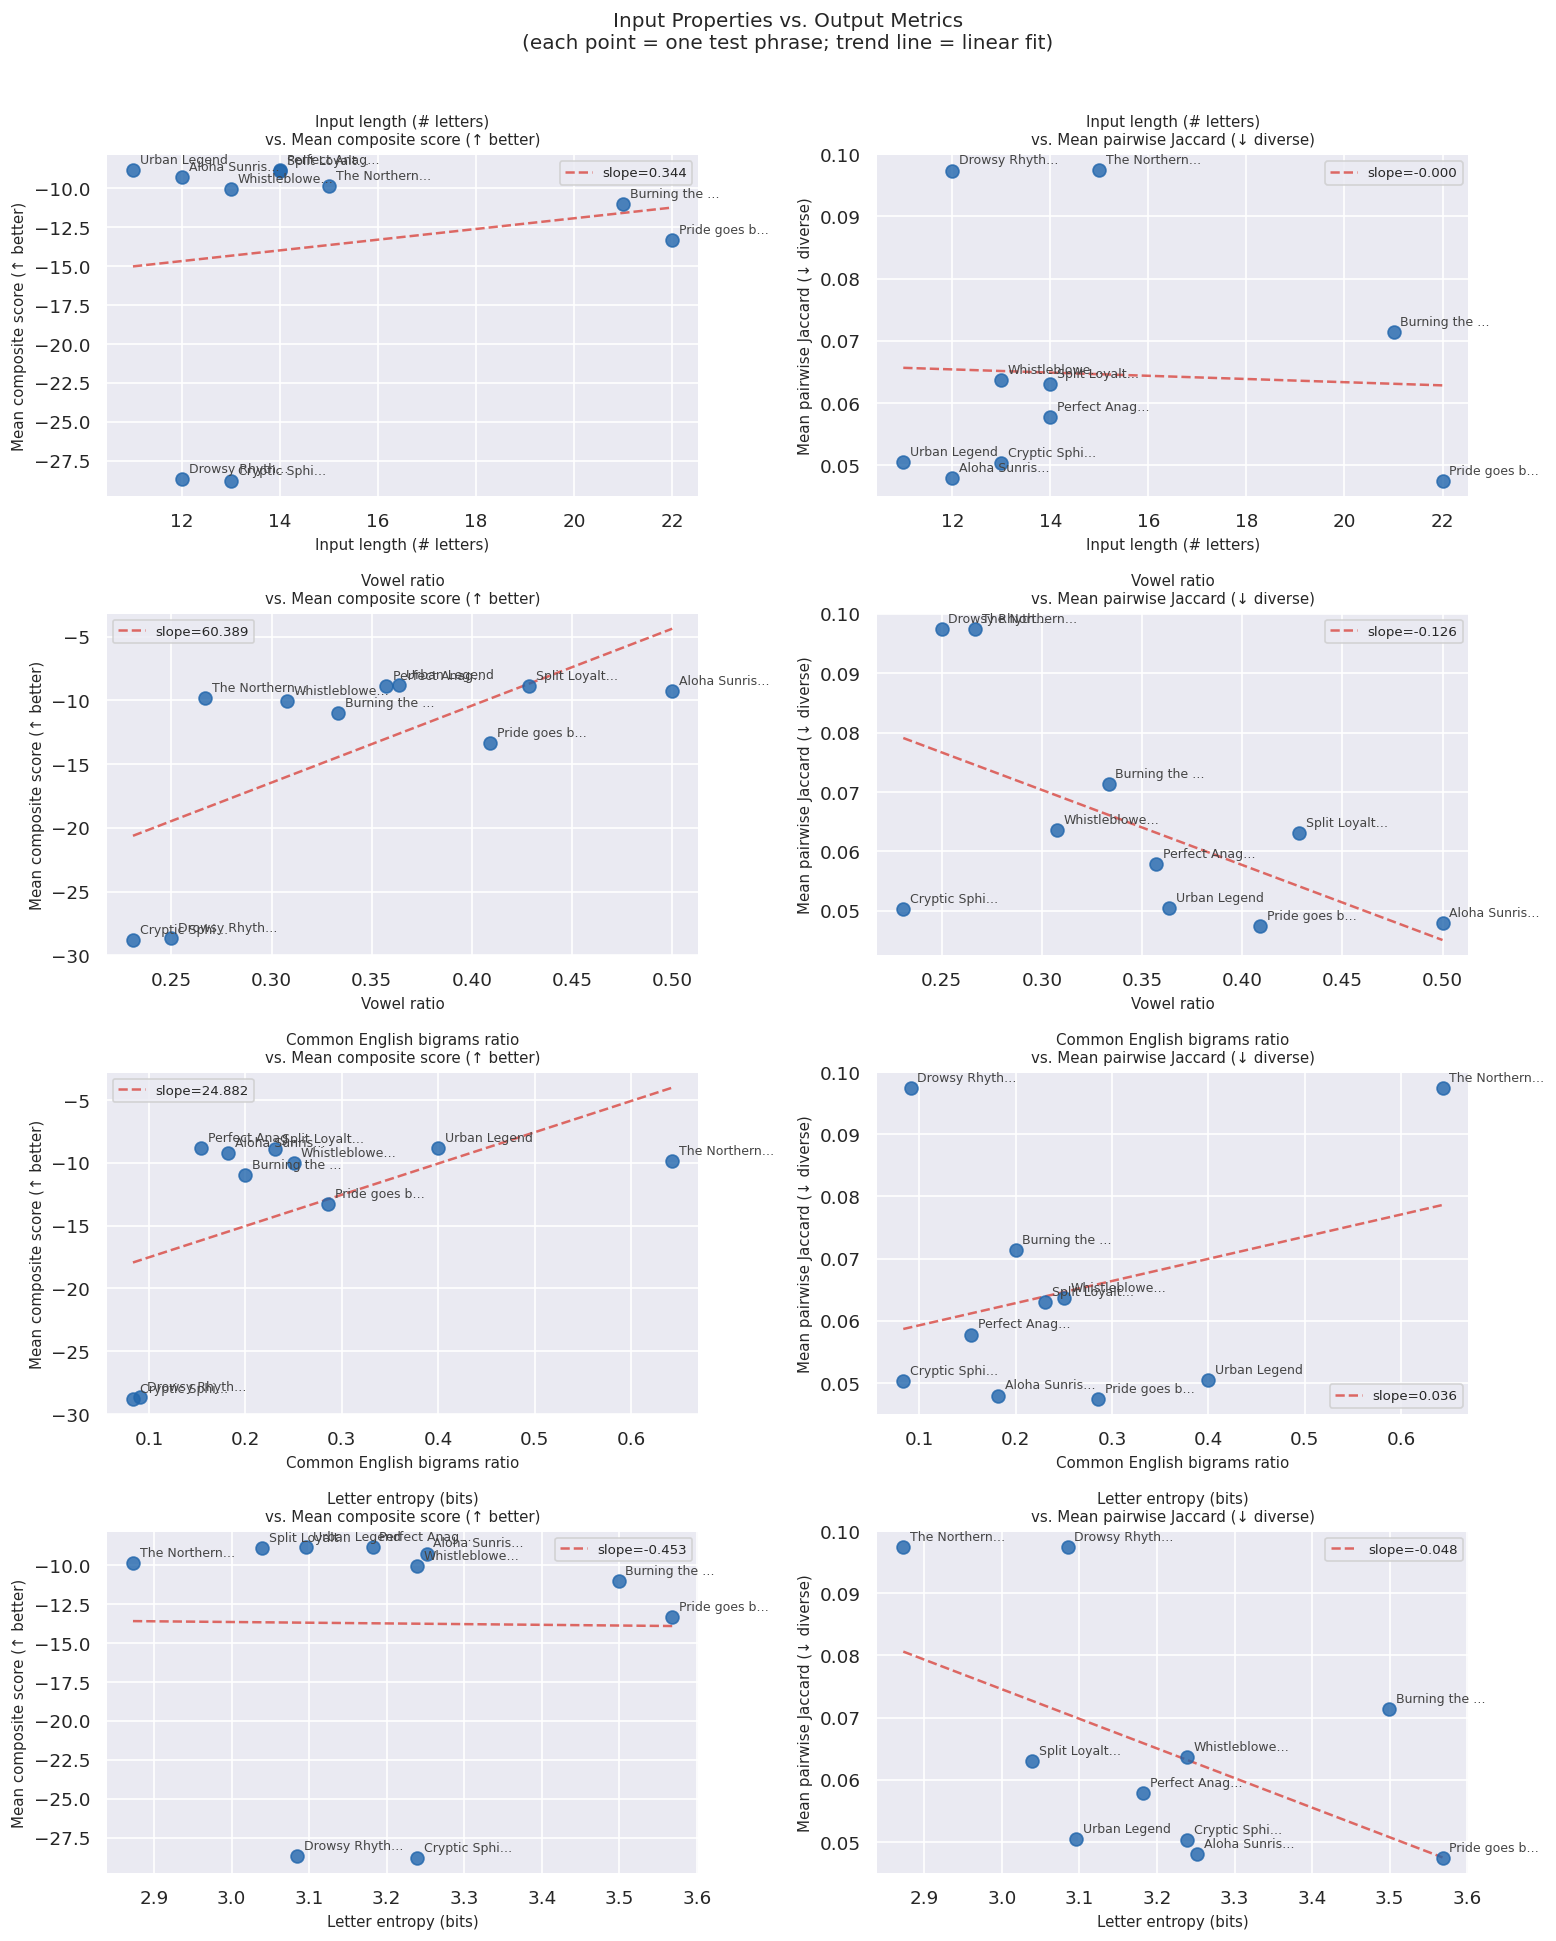

Saved → /home/kbest/github/bu-cds-llms-sp26-portfolio-piece-1-portfolio-piece-KristenBestavros/outputs/input_properties_scatter.png


In [30]:
# ---------------------------------------------------------------------------
# Compute input properties for each test phrase
# ---------------------------------------------------------------------------
COMMON_BIGRAMS = {
    "th", "he", "in", "er", "an", "re", "on", "en", "at", "es",
    "st", "al", "ar", "to", "or", "se", "le", "nd", "ea", "it",
}

def letter_entropy(s):
    """Shannon entropy (bits) of letter frequency distribution."""
    from collections import Counter
    counts = Counter(s)
    total = sum(counts.values())
    if total == 0:
        return 0.0
    return -sum((c/total) * math.log2(c/total) for c in counts.values())

prop_rows = []
for phrase in TEST_PHRASES:
    letters = normalize(phrase)
    n = len(letters)
    vowel_r = sum(1 for c in letters if c in VOWELS) / n if n > 0 else 0.0
    bigram_count = sum(
        1 for i in range(len(letters) - 1) if letters[i:i+2] in COMMON_BIGRAMS
    )
    bigram_ratio = bigram_count / (n - 1) if n > 1 else 0.0
    entropy = letter_entropy(letters)
    prop_rows.append({
        "phrase": phrase,
        "n_letters": n,
        "vowel_ratio": vowel_r,
        "common_bigram_ratio": bigram_ratio,
        "letter_entropy": entropy,
    })

df_props = pd.DataFrame(prop_rows)

# ---------------------------------------------------------------------------
# Generate output metrics for each phrase (default settings)
# ---------------------------------------------------------------------------
out_rows = []
for phrase in TEST_PHRASES:
    random.seed(42)
    results = _gen.generate(phrase, n_results=30)
    scores = [s for _, s, _, _ in results]
    names  = [n for n, _, _, _ in results]
    out_rows.append({
        "phrase":               phrase,
        "mean_score":           float(np.mean(scores)) if scores else float("nan"),
        "mean_pairwise_jaccard": mean_pairwise_jaccard(names),
    })

df_out = pd.DataFrame(out_rows)
df_analysis = df_props.merge(df_out, on="phrase")

# Short phrase labels for scatter annotation
df_analysis["label"] = df_analysis["phrase"].apply(
    lambda p: p[:12] + "\u2026" if len(p) > 12 else p
)

print("Input properties and output metrics:")
display(df_analysis.drop(columns="label").round(3))

# ---------------------------------------------------------------------------
# 4×2 scatter grid: input property × output metric
# ---------------------------------------------------------------------------
INPUT_PROPS = [
    ("n_letters",           "Input length (# letters)"),
    ("vowel_ratio",         "Vowel ratio"),
    ("common_bigram_ratio", "Common English bigrams ratio"),
    ("letter_entropy",      "Letter entropy (bits)"),
]
OUTPUT_METRICS = [
    ("mean_score",            "Mean composite score (\u2191 better)"),
    ("mean_pairwise_jaccard", "Mean pairwise Jaccard (\u2193 diverse)"),
]

fig, axes = plt.subplots(4, 2, figsize=(13, 16))

for row_idx, (prop_col, prop_label) in enumerate(INPUT_PROPS):
    for col_idx, (metric_col, metric_label) in enumerate(OUTPUT_METRICS):
        ax = axes[row_idx][col_idx]

        x = df_analysis[prop_col].values
        y = df_analysis[metric_col].values

        ax.scatter(x, y, color="#2166ac", s=60, zorder=3, alpha=0.8)

        # Annotate each point with the short phrase label
        for _, row in df_analysis.iterrows():
            ax.annotate(
                row["label"],
                (row[prop_col], row[metric_col]),
                xytext=(4, 4), textcoords="offset points",
                fontsize=7.5, color="#444",
            )

        # Linear trend line
        if len(x) > 1 and not np.isnan(y).any():
            m, b = np.polyfit(x, y, 1)
            xr = np.linspace(x.min(), x.max(), 100)
            ax.plot(xr, m * xr + b, color="#d73027", linewidth=1.5,
                    linestyle="--", alpha=0.7, label=f"slope={m:.3f}")
            ax.legend(fontsize=8, loc="best")

        ax.set_xlabel(prop_label, fontsize=9)
        ax.set_ylabel(metric_label, fontsize=9)
        ax.set_title(f"{prop_label}\nvs. {metric_label}", fontsize=9, pad=6)

plt.suptitle(
    "Input Properties vs. Output Metrics\n"
    "(each point = one test phrase; trend line = linear fit)",
    fontsize=12, y=1.01,
)
plt.tight_layout()

out_path = OUTPUT_DIR / "input_properties_scatter.png"
plt.savefig(out_path, dpi=120, bbox_inches="tight")
plt.show()
print(f"Saved \u2192 {out_path}")

### Interpretation

- **n_letters**: Input length does not seem to have a statistically significant impact on either score or diversity; that said, I notice that, ignoring the "Cryptic Sphinx" and "Drowsy Rhythm" outliers, the two longest phrases -- "Burning the midnight oil" and "Pride goes before the fall" have lower scores than shorter phrases. In comparison, there is no discernible relationship between length and diversity, even ignoring outliers -- despite being only one letter apart, "Burning the midnight oil" and "Pride goes before the fall" have significantly different diversity scores.

- **vowel_ratio**: These graphs show one of the strongest relationships overall. There is a statistically significant positive relationship between vowel ratio and score, and in inverse relationship between vowel ratio and diversity. This makes sense since we have phonotactic rules in place governing the use of vowels, so the more vowels there are, the more we will see those rules leading to more deterministic results. More vowels also means more ways to make pronounceable names, so the positive relationship with score is also expected.

- **common_bigram_ratio**: Here we look at the number of common English bigrams, normalized by phrase length, and its relationship to score and diversity. These graphs also show a strong relationship between bigram ratio and score, however I think it's worth noting that the outliers may once again be skewing things. Ignoring these, it looks like the relationship between bigram ratio and score would actually be very small. The relationship of bigram ratio to diversity is more clear -- with more common, high-scoring bigrams available to choose from, the model will produce less diverse results. This is as expected.

- **letter_entropy**: High entropy means more distinct letters,
  which gives the solver more degrees of freedom to produce varied outputs. It makes sense, then, that these graphs show a strong relationship between letter entropy and diversity, but a negligible relationship with score.

Overall, it looks like the most successful input phrases are medium-length, with a balanced vowel ratio and a middling ratio of common bigrams. Letter entropy improves diversity but has little impact on score.


# 8. Embedding Analysis: Generated Names vs. Real Names

This section is more for fun than for serious analysis. We've talked about word embeddings several times in class, and the subject of proper nouns has come up a few times -- we found that certain tokenizers recognize common names as a single token, while less common names are split into many parts. This made me curious as to how names generated by the anagrammer would show up in embedding space, and how they would appear relative to real names. We can also distinguish between male and female generated names to see if they appear differently in embedding space.

**Method:**
1. **Word2Vec on character n-grams** — train on all training names (male + female
   + surname), treating each name as a "sentence" of overlapping 2-grams and 3-grams.
   This is analogous to FastText's subword approach: phonotactically similar names
   share n-grams and therefore receive similar embeddings.
2. **Mean-pool n-gram vectors** — each name (real or generated) is represented as
   the mean of its character n-gram vectors (64-dimensional).
3. **t-SNE** (perplexity=40, L2-normalised inputs) reduces to 2D for visual inspection.
   Categories are coloured; real names use circles, generated segments use ✕ markers.
4. **Nearest-neighbour cosine similarity** — for each generated segment, find the
   closest real name in embedding space. Report mean similarity per generator model,
   then break down by real-name category to test whether outputs from the male model
   are indeed closer to real male names than to real female names.

**Data:**
| Split | Source | Count |
|---|---|---|
| real-male | 500 random from `male_first.txt` | 500 |
| real-female | 500 random from `female_first.txt` | 500 |
| real-surname | 500 random from `surnames.txt` | 500 |
| gen-male | non-trivial segments from Section 5, `dataset="male"` | ~530 |
| gen-female | non-trivial segments from Section 5, `dataset="female"` | ~530 |
| gen-both | non-trivial segments from Section 5, `dataset="both"` | ~530 |

**Disclaimer:** This is exploratory. The anagram constraint fixes the letter pool to
only 10 test phrases, which may force generated segments to cluster together
regardless of which model produced them. Additionally, the results may prove meaningless even accounting for anagram restraints. Regardless, I think it is an interesting thing to investigate.

In [19]:

from gensim.models import Word2Vec
from sklearn.preprocessing import normalize as sk_normalize

NGRAM_SIZES = [2, 3]
N_REAL_EACH = 500
EMBED_SEED  = SEED        # same global seed for reproducibility
DATA_DIR    = ANAGRAMMER_DIR / "data"

# ---------------------------------------------------------------------------
# Character n-gram helpers
# ---------------------------------------------------------------------------

def char_ngrams(name, sizes=NGRAM_SIZES):
    """Return all overlapping character n-grams for the given sizes."""
    s = name.lower().strip()
    result = []
    for n in sizes:
        for i in range(len(s) - n + 1):
            result.append(s[i : i + n])
    return result


def embed_name(name, model, sizes=NGRAM_SIZES):
    """Mean-pool character n-gram vectors.

    Returns a float32 array of shape (vector_size,), or None if no n-gram
    from this name appears in the model vocabulary.
    """
    vecs = [model.wv[ng] for ng in char_ngrams(name, sizes) if ng in model.wv]
    if not vecs:
        return None
    return np.mean(vecs, axis=0).astype(np.float32)


# ---------------------------------------------------------------------------
# Load training corpora (full, for Word2Vec training)
# ---------------------------------------------------------------------------

def load_names(path):
    with open(path) as fh:
        return [ln.strip().lower() for ln in fh if ln.strip()]

all_male    = load_names(DATA_DIR / "male_first.txt")
all_female  = load_names(DATA_DIR / "female_first.txt")
all_surname = load_names(DATA_DIR / "surnames.txt")

print(f"Corpus sizes:  male={len(all_male):,}  female={len(all_female):,}  "
      f"surname={len(all_surname):,}")

# ---------------------------------------------------------------------------
# Sample 500 real names from each corpus for the visualisation
# ---------------------------------------------------------------------------
_rng = random.Random(EMBED_SEED)
real_male    = _rng.sample(all_male,    N_REAL_EACH)
real_female  = _rng.sample(all_female,  N_REAL_EACH)
real_surname = _rng.sample(all_surname, N_REAL_EACH)

# ---------------------------------------------------------------------------
# Train Word2Vec on character n-grams from ALL training names
# ---------------------------------------------------------------------------
# Each name becomes a "sentence" of overlapping 2-grams and 3-grams.
# min_count=1: keep every n-gram; generated names may hit rare combinations
# due to the anagram constraint forcing unusual letter sequences.
# sg=1 (skip-gram) works better than CBOW for short, sparse sentences.

all_training = all_male + all_female + all_surname
sentences    = [char_ngrams(name) for name in all_training]
sentences    = [s for s in sentences if s]   # drop empty (very short names)

print(f"\nWord2Vec training: {len(sentences):,} sentences, "
      f"{sum(len(s) for s in sentences):,} total tokens")

np.random.seed(EMBED_SEED)
w2v = Word2Vec(
    sentences,
    vector_size=64,
    window=3,         # within a name, nearby n-grams co-occur regularly
    min_count=1,
    sg=1,             # skip-gram
    workers=4,
    seed=EMBED_SEED,
    epochs=10,
)
print(f"Vocabulary: {len(w2v.wv):,} unique character n-grams")

# ---------------------------------------------------------------------------
# Build unified record list: real + generated segments
# ---------------------------------------------------------------------------
# Categories:  real-male, real-female, real-surname
#              gen-male,  gen-female,  gen-both
CAT_ORDER = ["real-male", "real-female", "real-surname",
             "gen-male",  "gen-female",  "gen-both"]

CAT_COLOR = {
    "real-male":    "#4878d0",   # medium blue
    "real-female":  "#ee854a",   # orange
    "real-surname": "#6acc65",   # green
    "gen-male":     "#1a3f8a",   # dark blue
    "gen-female":   "#b53a00",   # dark orange
    "gen-both":     "#1a6b1a",   # dark green
}
CAT_MARKER = {k: "o" if "real" in k else "X" for k in CAT_ORDER}
CAT_SIZE   = {k: 14  if "real" in k else 45  for k in CAT_ORDER}
CAT_ALPHA  = {k: 0.35 if "real" in k else 0.75 for k in CAT_ORDER}

records = []
for name in real_male:
    records.append({"name": name, "category": "real-male",    "is_real": True})
for name in real_female:
    records.append({"name": name, "category": "real-female",  "is_real": True})
for name in real_surname:
    records.append({"name": name, "category": "real-surname", "is_real": True})
for ds in DATASETS:
    cat = f"gen-{ds}"
    for seg in seg_by_ds[ds]:
        records.append({"name": seg, "category": cat, "is_real": False})

# Compute embeddings; drop any name with zero vocabulary coverage
embeddings    = []
valid_records = []
n_missing     = 0
for rec in records:
    vec = embed_name(rec["name"], w2v)
    if vec is not None:
        embeddings.append(vec)
        valid_records.append(rec)
    else:
        n_missing += 1

X      = np.vstack(embeddings)                        # (N, 64)
df_emb = pd.DataFrame(valid_records).reset_index(drop=True)

print(f"\nEmbedded {len(df_emb):,} entries  ({n_missing} skipped — no vocab hits)")
print(f"Embedding matrix: {X.shape}")
print("\nCounts per category:")
print(df_emb["category"].value_counts().reindex(CAT_ORDER).to_string())


Corpus sizes:  male=47,510  female=39,414  surname=18,905

Word2Vec training: 105,829 sentences, 1,155,295 total tokens


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


Vocabulary: 10,810 unique character n-grams

Embedded 3,767 entries  (0 skipped — no vocab hits)
Embedding matrix: (3767, 64)

Counts per category:
category
real-male       500
real-female     500
real-surname    500
gen-male        750
gen-female      757
gen-both        760


Running t-SNE on 3767 points × 64 dims…
(perplexity=40, max_iter=1000, init=pca  — may take 1-2 min)
t-SNE complete.


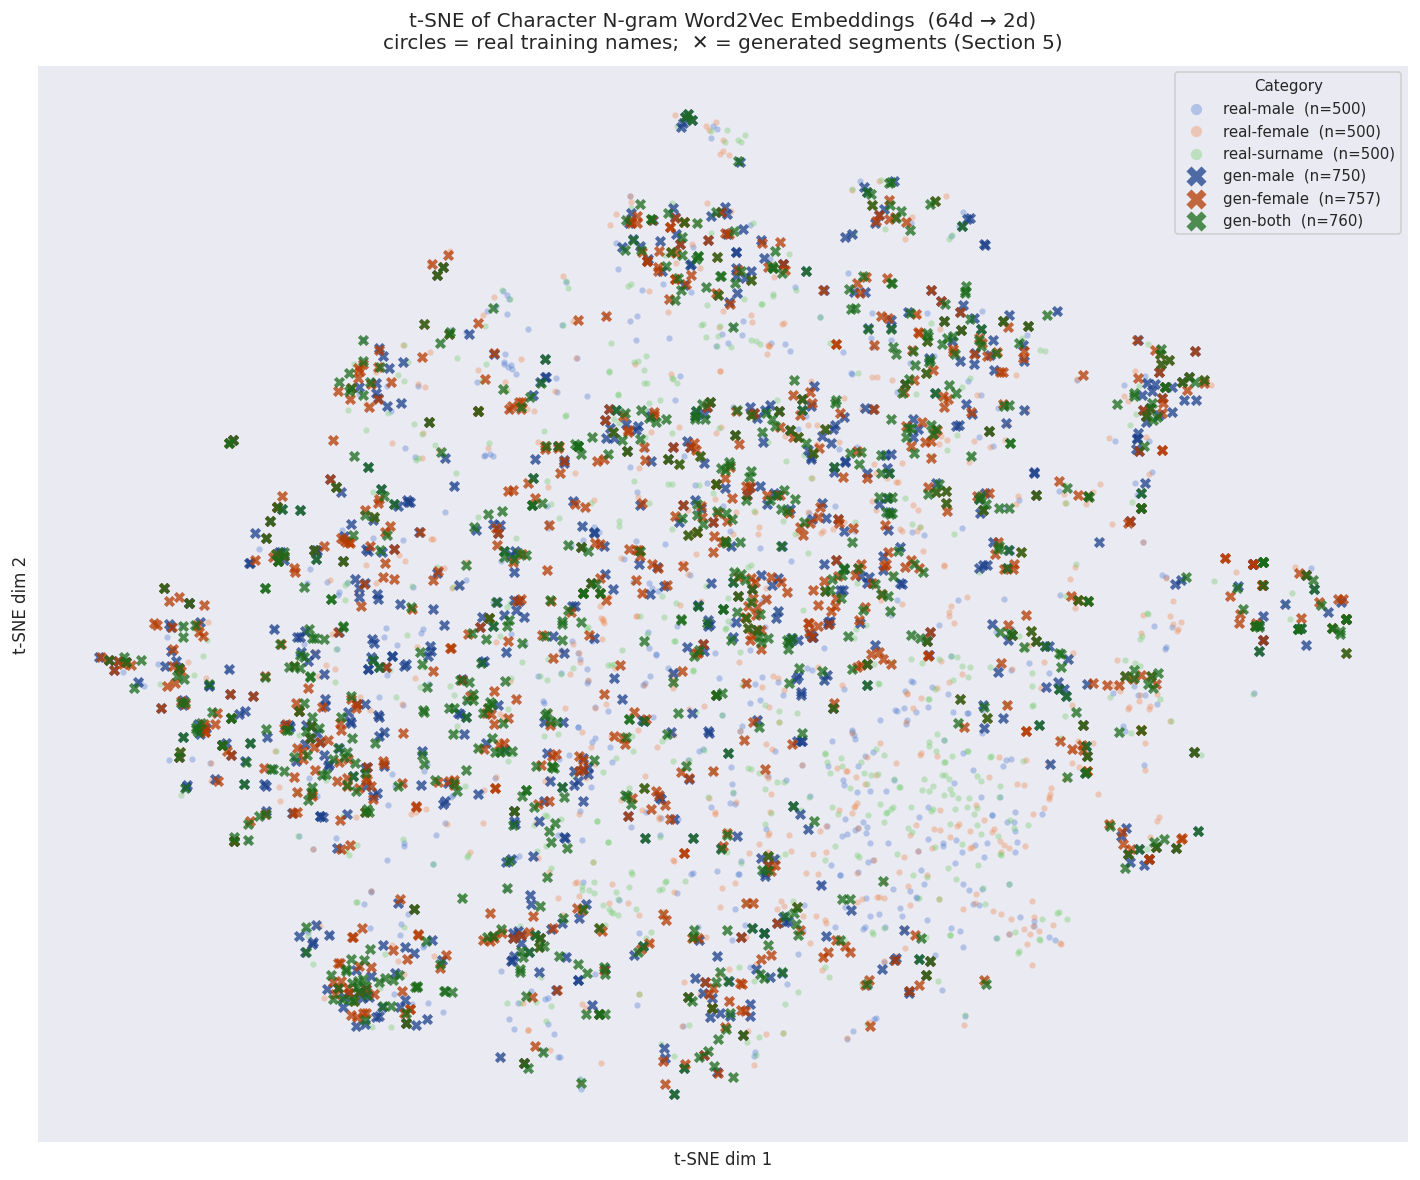

Saved → /home/kbest/github/bu-cds-llms-sp26-portfolio-piece-1-portfolio-piece-KristenBestavros/outputs/embedding_clusters.png


In [20]:

from sklearn.manifold import TSNE

# ---------------------------------------------------------------------------
# t-SNE dimensionality reduction
# ---------------------------------------------------------------------------
# L2-normalise first: cosine-based t-SNE is equivalent to Euclidean distance
# on unit-norm vectors, and normalisation removes scale differences between
# short and long names without changing relative angles.

X_norm = sk_normalize(X, norm="l2")

print(f"Running t-SNE on {X_norm.shape[0]} points × {X_norm.shape[1]} dims…")
print("(perplexity=40, max_iter=1000, init=pca  — may take 1-2 min)")

np.random.seed(EMBED_SEED)
tsne = TSNE(
    n_components=2,
    perplexity=40,
    max_iter=1000,
    init="pca",               # more stable than random init
    learning_rate="auto",
    random_state=EMBED_SEED,
)
X_2d = tsne.fit_transform(X_norm)
df_emb["tx"] = X_2d[:, 0]
df_emb["ty"] = X_2d[:, 1]
print("t-SNE complete.")

# ---------------------------------------------------------------------------
# Scatter plot
# ---------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(12, 10))

for cat in CAT_ORDER:
    sub = df_emb[df_emb["category"] == cat]
    if sub.empty:
        continue
    ax.scatter(
        sub["tx"], sub["ty"],
        c=CAT_COLOR[cat],
        marker=CAT_MARKER[cat],
        s=CAT_SIZE[cat],
        alpha=CAT_ALPHA[cat],
        linewidths=0,
        label=f"{cat}  (n={len(sub)})",
        zorder=3 if "gen" in cat else 2,
    )

ax.set_title(
    "t-SNE of Character N-gram Word2Vec Embeddings  (64d → 2d)\n"
    "circles = real training names;  ✕ = generated segments (Section 5)",
    fontsize=12,
    pad=10,
)
ax.set_xlabel("t-SNE dim 1", fontsize=10)
ax.set_ylabel("t-SNE dim 2", fontsize=10)
ax.set_xticks([])
ax.set_yticks([])
ax.legend(
    fontsize=9,
    title="Category",
    title_fontsize=9,
    markerscale=1.8,
    framealpha=0.85,
    loc="upper right",
)

plt.tight_layout()
out_path = OUTPUT_DIR / "embedding_clusters.png"
plt.savefig(out_path, dpi=120, bbox_inches="tight")
plt.show()
print(f"Saved → {out_path}")


In [21]:

from sklearn.metrics.pairwise import cosine_similarity as cos_sim
from IPython.display import display

# ---------------------------------------------------------------------------
# Nearest-neighbour cosine similarity: generated segments vs. real names
# ---------------------------------------------------------------------------
# L2-normalise so dot-product == cosine similarity for fast batch computation.

X_norm = sk_normalize(X, norm="l2")

is_real = df_emb["is_real"].values.astype(bool)
X_real  = X_norm[is_real]
X_gen   = X_norm[~is_real]
cats_real = df_emb["category"].values[is_real]
cats_gen  = df_emb["category"].values[~is_real]

# sim_all[i, j] = cosine similarity between generated[i] and real[j]
sim_all = cos_sim(X_gen, X_real)          # (n_gen, n_real)
nn_sim  = sim_all.max(axis=1)             # nearest real-name sim for each gen seg

# ── Table 1: Overall nearest-real-name similarity by generator ──────────────
df_sim = pd.DataFrame({"generator": cats_gen, "nn_sim": nn_sim})

agg_nn = (
    df_sim
    .groupby("generator")["nn_sim"]
    .agg(n="count", mean="mean", median="median", std="std",
         p10=lambda x: x.quantile(0.10), p90=lambda x: x.quantile(0.90))
    .loc[["gen-male", "gen-female", "gen-both"]]
    .round(4)
)
agg_nn.index.name = "Generator"
print("Nearest-real-name cosine similarity  (generated segments vs. all real names):")
print("(higher = segment is closer to at least one real name in n-gram space)")
display(agg_nn)

# ── Table 2: Cross-category breakdown ──────────────────────────────────────
# For each (gen_category, real_category) pair: mean nearest-neighbour similarity.
# If gen-male is measurably closer to real-male than to real-female, the model's
# corpus-level gender bias is detectable in embedding space.
cross_rows = []
for gen_cat in ["gen-male", "gen-female", "gen-both"]:
    gen_mask  = cats_gen == gen_cat
    X_g       = X_gen[gen_mask]
    row       = {"generator": gen_cat}
    for real_cat in ["real-male", "real-female", "real-surname"]:
        real_mask = cats_real == real_cat
        X_r       = X_real[real_mask]
        nn        = cos_sim(X_g, X_r).max(axis=1).mean()
        row[real_cat] = round(float(nn), 4)
    cross_rows.append(row)

df_cross = (
    pd.DataFrame(cross_rows)
    .set_index("generator")
)
df_cross.index.name   = "Generator"
df_cross.columns.name = "Real category"

print("\nCross-category nearest-neighbour cosine similarity:")
print("(row = generator model;  column = real-name category used as reference)")
display(df_cross)

# ── Summary: which real category is each generator closest to? ──────────────
print("\nFor each generator, closest real category (highest mean nn-sim):")
for _, row in df_cross.iterrows():
    best = row.idxmax()
    print(f"  {row.name:12s}  →  {best}  ({row[best]:.4f})")


Nearest-real-name cosine similarity  (generated segments vs. all real names):
(higher = segment is closer to at least one real name in n-gram space)


,n,mean,median,std,p10,p90
Generator,,,,,,
gen-male,750,0.8887,0.8921,0.0356,0.8445,0.9282
gen-female,757,0.8892,0.8900,0.0373,0.8419,0.9348
gen-both,760,0.8889,0.8902,0.0357,0.8437,0.9291



Cross-category nearest-neighbour cosine similarity:
(row = generator model;  column = real-name category used as reference)


Real category,real-male,real-female,real-surname
Generator,,,
gen-male,0.8623,0.8571,0.8608
gen-female,0.8609,0.8601,0.8612
gen-both,0.8623,0.8583,0.8611



For each generator, closest real category (highest mean nn-sim):
  gen-male      →  real-male  (0.8623)
  gen-female    →  real-surname  (0.8612)
  gen-both      →  real-male  (0.8623)



### Interpretation

The t-SNE plot shows no visible separation between any of the six categories: generated segments (✕ markers) are distributed throughout the same region as all three real-name categories, and real-male, real-female, and real-surname are themselves intermingled. This is consistent with the known limitation of unsupervised character n-gram embeddings: co-occurrence structure organizes names by shared phonotactic patterns broadly, not by gender or register. As such, the absence of distinct clusters is not a failure of name generation, and simply shows that generated segments inhabit the same broad phonotactic space as real training names.

***Cosine Similarity: ~0.89***

All three generators show essentially identical overall nearest-neighbor similarity (~0.89), well above 0.5 (random) but below 1.0. Generated segments reliably land near real names in embedding space — they are phonotactically plausible — but not identical. The consistent p10 of ~0.845 means even the least name-like outputs remain in a real-name neighborhood. The small distance from 1.0 likely reflects the anagram constraint occasionally forcing unusual n-gram sequences.

***Cross-Category Table: Near-Uniform***

The full spread of the cross-category table is only 0.0058 (0.8580–0.8638 across all nine cells), which means the embedding space has almost no discriminative power along the male/female/surname axis. At this resolution, the differences are near the noise floor.

That said, the direction of the differences is consistent with the training data: gen-male and gen-both both show their highest affinity for real-male, by margins of 0.0049 and 0.0037 respectively. This is congruent with the dataset analysis in Section 5, where the male first-name corpus (~47,500 names) is larger than the female corpus (~39,400 names), and the "both" model may therefore inherit a mild male-phonotactic skew.

The anomaly is gen-female, which scores highest against real-surname (0.8630) rather than real-female (0.8612) — a gap of just 0.0018. One possible explanation is that the anagram constraint, combined with the shared surname model, pulls female-model segments toward surname-like phonotactic shapes (denser consonant endings, shorter syllable counts) when typical feminine suffixes are unavailable in the letter pool. It is also possible that female names and surnames simply overlap more in n-gram space than male names and surnames do in this embedding. Either way, it's a strange result, and may be worth examining further.

Overall, the limits of applying embeddings at the letter level makes this analysis somewhat academic, but still fun to explore.

# 7. Conclusions and Future Work

For future development, there are a number of possible improvements with varying degrees of feasibility. After seeing the discrepency between male and female naming, I am convinced that I have to do something to compensate for the different database sizes, though I am admittedly not sure of the best way to do this. A simpler improvement I can make very easily is the temperature range and defaults. I also think implementing top-k selection for inputs above a certain letter length could prove beneficial -- this is slightly more work than the simple temperature change, but may be worthwhile.

Another potential route for future developement is culture awareness. The training data has names from practically every culture across the world, which each have different naming conventions. Some of these naming conventions contradict each other -- for example, cultures for which names ending in -a are masculine vs. feminine. I worry that having all of these names in one dataset is reducing the anagrammer's ability to discern patterns. This issue is not a simple one to address -- I do not want to add a million style flags for the user to sort through, especially since I would also have to include male/female options for each, and ultimately I think training a bunch of models on very thin data is decidedly worse than aggregating all the data and training one model, even if that model can't know specific cultural naming conventions. I considered briefly grouping cultures by continent to reduce complexity and combat thin datasets, but this has the issue of overgeneralizing and perpetuating harmful stereotypes. Because of all these issues, I have tabled the issue for now, but may consider returning to address it at a later date.

One easy thing I've been considering is separating the surname data from the first name data. I find the idea even more appealing now that I know the female generated names share more in common with real surnames than real female names. Of course, the surname data is comparatively much smaller than the first name data, but at roughly 16,000 names I think it's still big enough to train a model on.

Overall, the anagrammer in its current state performs admirably and has sound feature design. The analysis done here has helped me consider places where the model could be improved. I did not realize that the female names model was not performing at the level of the male names model, for example, nor did I realize that my default temperature is actually the worst performing temperature. It was also very interesting to apply the concepts we learned in class to this project, since the applications are so different when working at the letter level. I admit that after the lecture about top-k and top-p, I didn't understand why anyone would use top-k when top-p can account for the actual probabilities. My own analysis showed me the value of top-k in certain cases, though, and I think I understand it better now. I found this analysis quite rewarding and am looking forward to developing this tool further.